- **Author:** `Hunter Worssam`  
- **Date:** `2025-10-03`  
- **Title:** `Complete Supervised and Unsupervised Learning Model Implementation`
- **Supervised Models:** `Logistic Regression, K-Nearest Neighbors (KNN), Naive Bayes, Support Vector Machine (SVM), Decision Tree, Random Forest, Gradient Boosting, Neural Network (use PyTorch)`
- **Unsupervised Models:** `K-Means, Hierarchical Clustering, Gaussian Mixture Model, Self-Organizing Map, Density-Based Spatial Clustering of Applications with Noise (DBSCAN)`

## README (Execution & Setup)
- **Python version:** `3.10.18`
- **Required packages** (core): numpy, pandas, scikit-learn, matplotlib, seaborn, scipy, torch, minisom
- **Install instructions:**
  ```bash
  # pip install numpy pandas scikit-learn matplotlib seaborn scipy torch minisom
  ```
- **Datasets used:**
  - File needed in your local directory: 'heart_disease_uci.csv' and 'Mall_Customers.csv'.
  - https://www.kaggle.com/datasets/redwankarimsony/heart-disease-data/data
  - https://www.kaggle.com/datasets/datazng/shopping-mall-customer-data-segmentation-analysis/data
- **How to run this notebook:**
  1. Run all cells in order (Kernel → Restart & Run All).
  2. Ensure figures and tables render correctly.


In [3]:
# Standard library
import itertools
import os
import platform
import re
import sys
import warnings
from pathlib import Path

# Third-party
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Ellipse
from minisom import MiniSom
from scipy.cluster.hierarchy import dendrogram, fcluster, linkage
from scipy.spatial.distance import pdist
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.cluster import DBSCAN, KMeans
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import GradientBoostingClassifier, IsolationForest, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    RocCurveDisplay,
    accuracy_score,
    adjusted_rand_score,
    auc,
    classification_report,
    make_scorer,
    normalized_mutual_info_score,
    precision_recall_fscore_support,
    roc_auc_score,
    roc_curve,
    silhouette_score,
)
from sklearn.mixture import BayesianGaussianMixture, GaussianMixture
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

# Warnings
warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
    message=re.escape("Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated"),
)

In [4]:
# Environment Check 
print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
try:
    import numpy as np, pandas as pd
    print("NumPy:", np.__version__)
    print("Pandas:", pd.__version__)
except Exception as e:
    print("Optional packages missing or version check failed:", e)

Python: 3.10.18
Platform: macOS-15.6.1-arm64-arm-64bit
NumPy: 1.26.4
Pandas: 2.3.2


# Supervised Learning Techniques Comparison

Here we evaluate and compare the performance of various supervised learning models: Logistic Regression, KNN, Naive Bayes, SVM, Decision Trees, Random Forest, Gradient Boosting, and Neural Networks.


## (a) Data Preprocessing:
- Loading data, handling missing values via median imputation and KNN imputation and scaling the continuous feature values using the standard scaler.

We can begin this problem by loading in the heart dataset, exploring the header, and then performing some basic EDA to get an understanding of data types, column ranges and missingness in the dataset. 

In [8]:
# Loading the Data
CSV_PATH = "heart_disease_uci.csv"  
df = pd.read_csv(CSV_PATH)
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [9]:
# Dtypes
print("=== Data types ===")
print(df.dtypes)

=== Data types ===
id            int64
age           int64
sex          object
dataset      object
cp           object
trestbps    float64
chol        float64
fbs          object
restecg      object
thalch      float64
exang        object
oldpeak     float64
slope        object
ca          float64
thal         object
num           int64
dtype: object


In [10]:
force_categorical = {"ca", "num"}
present_force = [c for c in df.columns if c.lower() in {x.lower() for x in force_categorical}]

for col in present_force:
    # if numeric, keep integer codes but as category; otherwise just cast to category
    if pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].astype("Int64").astype("category")
    else:
        df[col] = df[col].astype("category")

# Now build numeric list excluding forced categoricals
num_cols_initial = [c for c in df.select_dtypes(include=[np.number]).columns if c not in present_force]

# Numeric summary with explicit min/max
print("=== Numeric summary & ranges (excluding ca/num) ===")
if num_cols_initial:
    desc = df[num_cols_initial].describe().T
    desc["range_min"] = df[num_cols_initial].min()
    desc["range_max"] = df[num_cols_initial].max()
    display(desc)
else:
    print("No numeric columns remaining after exclusions.")

=== Numeric summary & ranges (excluding ca/num) ===


,count,mean,std,min,25%,50%,75%,max,range_min,range_max
id,920.0,460.500000,265.725422,1.0,230.75,460.5,690.25,920.0,1.0,920.0
age,920.0,53.510870,9.424685,28.0,47.00,54.0,60.00,77.0,28.0,77.0
trestbps,861.0,132.132404,19.066070,0.0,120.00,130.0,140.00,200.0,0.0,200.0
chol,890.0,199.130337,110.780810,0.0,175.00,223.0,268.00,603.0,0.0,603.0
thalch,865.0,137.545665,25.926276,60.0,120.00,140.0,157.00,202.0,60.0,202.0
oldpeak,858.0,0.878788,1.091226,-2.6,0.00,0.5,1.50,6.2,-2.6,6.2


Our data is comprised of 6 numerical columns and 10 categorical columns. "Num" will serve as our target variable for severity of heart disease.

In [12]:
# Collect categorical columns (includes forced)
cat_cols_initial = sorted(set(df.select_dtypes(include=["object", "category"]).columns) | set(present_force))

if cat_cols_initial:
    print("\n=== Categorical columns top counts (includes ca/num) ===")
    for c in cat_cols_initial:
        print(f"\n{c} (nunique={df[c].nunique(dropna=False)}):")
        display(df[c].value_counts(dropna=False).head(10))
else:
    print("No categorical columns found.")


=== Categorical columns top counts (includes ca/num) ===

ca (nunique=5):


ca
NaN    611
0      181
1       67
2       41
3       20
Name: count, dtype: int64


cp (nunique=4):


cp
asymptomatic       496
non-anginal        204
atypical angina    174
typical angina      46
Name: count, dtype: int64


dataset (nunique=4):


...

sex
Male      726
Female    194
Name: count, dtype: int64


slope (nunique=4):


slope
flat           345
NaN            309
upsloping      203
downsloping     63
Name: count, dtype: int64


thal (nunique=4):


thal
NaN                  486
normal               196
reversable defect    192
fixed defect          46
Name: count, dtype: int64

We have a predominantly male dataset (726 vs 194), with data gathered from four unique locations. There exists a higher proportion of NAN values in the ca, fbs, exang, slope and thal columns. Let's observe the numerical columns for missingness as well. 

In [14]:
# Missingness table
missing = df.isna().sum().to_frame("n_missing")
missing["pct_missing"] = (missing["n_missing"] / len(df)).round(4)
print("\n=== Missingness summary ===")
display(missing.sort_values("n_missing", ascending=False))


=== Missingness summary ===


,n_missing,pct_missing
ca,611,0.6641
thal,486,0.5283
slope,309,0.3359
fbs,90,0.0978
oldpeak,62,0.0674
trestbps,59,0.0641
thalch,55,0.0598
exang,55,0.0598
chol,30,0.0326
restecg,2,0.0022


As previously observed, the bulk of our missingness is from the "ca", "thal", "slope", and "fbs" columns. Before we leevrage an imputation method, let's see if any of this missingness is tied to the dataset (location) column.

In [16]:
cols = ["ca", "thal", "slope", "fbs", "oldpeak", "trestbps"]
assert "dataset" in df.columns, "Expected a 'dataset' column."
for c in cols:
    if c not in df.columns:
        raise KeyError(f"Column '{c}' not found in df.")

# Counts and percentages of missing per dataset
group_sizes = df.groupby("dataset").size().rename("n_rows")
miss_counts = df.groupby("dataset")[cols].apply(lambda g: g.isna().sum()).add_suffix("_nmiss")

missing_by_dataset = pd.concat([group_sizes, miss_counts], axis=1)
display(missing_by_dataset.sort_index())

,n_rows,ca_nmiss,thal_nmiss,slope_nmiss,fbs_nmiss,oldpeak_nmiss,trestbps_nmiss
dataset,,,,,,,
Cleveland,304,5,3,1,0,0,0
Hungary,293,290,265,189,8,0,1
Switzerland,123,118,52,17,75,6,2
VA Long Beach,200,198,166,102,7,56,56


It's clear from this table above that the missingness is not purely missing at random; in fact it's largely tied to the location that the data was generated. For the columns restecg (categorical), chol (numerical), exang (categorical), thalch (numerical), trestbps (numerical), fbs (categorical) and oldpeak(numerical) I will impute the missing data using the median or mode value of the given variable depending on if the data type is numerical or categorical respectively. Instead of using the global median or mode, I will use the location-specific median or mode given the relationship we've established between missingness and dataset location. Median should suffice as an imputation method since the mean and median values were comparable across our numerical data columns. Columns ca, thal and slope will be handled differently given the high percentage of missingness > 10% for each.

In [18]:
# --- config ---
GROUP_COL = "dataset"

numeric_wants     = ["chol", "thalch", "trestbps", "oldpeak"]
categorical_wants = ["restecg", "exang", "fbs"]

# --- helpers ---
def resolve_columns(df, wants):
    """Map desired names (case-insensitive, with aliases) to actual df columns."""
    lower_map = {c.lower(): c for c in df.columns}
    resolved = []
    for w in wants:
        lw = w.lower()
        if lw in lower_map:
            resolved.append(lower_map[lw])
    return list(dict.fromkeys(resolved)) 

def groupwise_median_impute(df, col, group_col):
    orig_dtype = df[col].dtype
    gmed = df.groupby(group_col)[col].transform("median")
    gmed_filled = gmed.fillna(df[col].median())
    df[col] = df[col].fillna(gmed_filled)

    # Make sure it's numeric (avoids object fallback)
    if not pd.api.types.is_numeric_dtype(df[col]):
        df[col] = pd.to_numeric(df[col], errors="coerce")
    try:
        df[col] = df[col].astype(orig_dtype)
    except Exception:
        pass

def groupwise_mode_impute(df, col, group_col):
    import numpy as np
    orig_dtype = df[col].dtype

    gmode = df.groupby(group_col)[col].transform(
        lambda s: s.mode(dropna=True).iloc[0] if s.notna().any() and not s.mode(dropna=True).empty else np.nan
    )
    global_mode = df[col].mode(dropna=True)
    global_mode_val = global_mode.iloc[0] if not global_mode.empty else np.nan

    fill_vals = gmode.fillna(global_mode_val)

    # >>> change here: infer dtypes explicitly after fillna
    df[col] = df[col].fillna(fill_vals)
    df[col] = df[col].infer_objects(copy=False)

    try:
        df[col] = df[col].astype(orig_dtype)
    except Exception:
        pass

# --- resolve requested columns present in df ---
assert GROUP_COL in df.columns, "Expected a 'dataset' column in df."
num_cols = resolve_columns(df, numeric_wants)
cat_cols = resolve_columns(df, categorical_wants)

print("Numeric to impute (median, by dataset):", num_cols)
print("Categorical to impute (mode, by dataset):", cat_cols)

# --- perform group-wise imputations ---
for c in num_cols:
    groupwise_median_impute(df, c, GROUP_COL)

for c in cat_cols:
    groupwise_mode_impute(df, c, GROUP_COL)

Numeric to impute (median, by dataset): ['chol', 'thalch', 'trestbps', 'oldpeak']
Categorical to impute (mode, by dataset): ['restecg', 'exang', 'fbs']


In [19]:
# Updated Missingness table
missing = df.isna().sum().to_frame("n_missing")
missing["pct_missing"] = (missing["n_missing"] / len(df)).round(4)
print("\n=== Missingness summary ===")
display(missing.sort_values("n_missing", ascending=False))


=== Missingness summary ===


,n_missing,pct_missing
ca,611,0.6641
thal,486,0.5283
slope,309,0.3359
id,0,0.0000
age,0,0.0000
sex,0,0.0000
dataset,0,0.0000
cp,0,0.0000
trestbps,0,0.0000
chol,0,0.0000


Given the large proportion of missingness observed in the "ca", "slope" and "thal" columns, I will use a random forest ensemble imputation method to fill in the gaps, paying close attention to the proportion of values under each column pre- and post- imputation. Thal and slope columns will be imputed using ensembles trained only on the "dataset" sub-populations because there exist enough labeled rows within each to train an accurate forest. Due to the extent of missingness in the "ca" column, a global forest ensemble will be used to derive the missing values, not taking into account the dataset value directly. When training the "ca" ensemble, slope and thal will be omitted from the training, and the same idea will be true for the training of the slope and thal-specific ensembles. *We will take note of the proportions of available data within these three columns pre-imputation so we can ensure minimal drift occurs in the distributions post-imputation.*

In [21]:
# Percent breakdown per categorical column (excluding NaN)
cat_cols_initial = ("ca", "slope", "thal")

print("\n=== Categorical columns percent breakdown (excluding NaN) ===")
for c in cat_cols_initial:
    col = df[c]
    n_total = len(col)
    n_valid = col.notna().sum()
    pct = (
        col.dropna()                      # remove NaN
           .value_counts(normalize=True)  # normalize by non-missing count
           .mul(100)
           .round(2)
           .rename("pct")
           .to_frame()
    )
    print(f"\n{c} (nunique_nonmissing={col.dropna().nunique()}, non-missing={n_valid}/{n_total}):")
    display(pct)


=== Categorical columns percent breakdown (excluding NaN) ===

ca (nunique_nonmissing=4, non-missing=309/920):


,pct
ca,
0,58.58
1,21.68
2,13.27
3,6.47



slope (nunique_nonmissing=3, non-missing=611/920):


,pct
slope,
flat,56.46
upsloping,33.22
downsloping,10.31



thal (nunique_nonmissing=3, non-missing=434/920):


,pct
thal,
normal,45.16
reversable defect,44.24
fixed defect,10.60


We note that in the case of the "ca" column, 58% of available data have a value of '0', 21.6% have a value of '1', and 13% have a value of '2'. For the slope column, 56% of the data have a value of 'flat', 33% have a value of 'upsloping', and 1-% have a value of 'downsloping'. For the thal column, roughly 45% of the data have a value of 'normal', 45% of the data have a value of 'reversable defect', and 10% of the data have a value of 'fixed defect'. We can now implement our random forest ensemble, using global dataset for the "ca" trees, and "dataset"-specific trees for the slope and thal values. We include an ALPHA_PRIOR weighting to favor values in-line with prior distributions, and we run 7 random forests per ensemble for better confidence in our predictions.

In [23]:
# Configuration
GROUP_COL      = "dataset"
RANDOM_STATE   = 42
N_ENS          = 7          # number of RFs in the ensemble
SAMPLE_FRAC    = 0.85       # bootstrap fraction per ensemble member
ALPHA_PRIOR    = 0.15       # blend weight toward observed class prior (0 - 1)
MATCH_PRIOR    = True       # force missing assignments to match the prior mix
MIN_CLASS_OBS  = 2          # require at least this many labeled rows per class to trust the prior

assert GROUP_COL in df.columns, f"Missing grouping column '{GROUP_COL}'."
for c in ["ca", "slope", "thal"]:
    assert c in df.columns, f"Missing column '{c}'."

# Treat targets as strings (keeps NA as <NA>)
for c in ["ca", "slope", "thal"]:
    if not pd.api.types.is_string_dtype(df[c]):
        df[c] = df[c].astype("string")

def build_preproc(X):
    cat_cols = X.select_dtypes(include=["object","category","string"]).columns.tolist()
    num_cols = [c for c in X.columns if c not in cat_cols]
    return ColumnTransformer(
        transformers=[
            ("cat", Pipeline([
                ("imp", SimpleImputer(strategy="most_frequent")),
                ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
            ]), cat_cols),
            ("num", Pipeline([
                ("imp", SimpleImputer(strategy="median")),
            ]), num_cols),
        ],
        remainder="drop"
    )

def _rf_proba_ensemble(X_train, y_train, X_test, n_ens=N_ENS, sample_frac=SAMPLE_FRAC, base_seed=RANDOM_STATE):
    """
    Average class probabilities across multiple RF fits, aligning to a fixed
    reference class set derived from ALL training labels (not per bootstrap).
    Handles bootstraps that drop a class (single-class fits) safely.
    """
    y_train = pd.Series(y_train).astype(str)
    classes_ref = np.array(sorted(y_train.unique()))  # fixed reference
    n_test = len(X_test)
    proba_sum = np.zeros((n_test, len(classes_ref)), dtype=float)

    n_train = len(X_train)
    for k in range(n_ens):
        rs = base_seed + 1000 * k
        # bootstrap (allow at least 1 row)
        boot_idx = np.random.RandomState(rs).choice(
            np.arange(n_train), size=max(1, int(round(sample_frac * n_train))), replace=True
        )
        Xb = X_train.iloc[boot_idx]
        yb = y_train.iloc[boot_idx]

        preproc = build_preproc(Xb)
        clf = Pipeline([
            ("prep", preproc),
            ("rf", RandomForestClassifier(
                n_estimators=400,
                max_depth=None,
                n_jobs=-1,
                class_weight="balanced_subsample",
                random_state=rs
            ))
        ])
        # If bootstrap degenerates to 1 unique class, RF still fits; proba has 1 column.
        clf.fit(Xb, yb)
        proba = clf.predict_proba(X_test)
        model_classes = clf.classes_.astype(str)

        # map model proba columns into reference order
        mapped = np.zeros((n_test, len(classes_ref)), dtype=float)
        for j, cls in enumerate(model_classes):
            j_ref = np.where(classes_ref == cls)[0]
            if j_ref.size:
                mapped[:, j_ref[0]] = proba[:, j]
            # if cls not in reference (shouldn't happen), ignore

        proba_sum += mapped

    return classes_ref, proba_sum / n_ens

def _blend_with_prior(proba, classes, prior, alpha=ALPHA_PRIOR):
    """Convex blend: p' = (1-alpha)*p + alpha*prior."""
    prior_vec = np.array([prior.get(cls, 0.0) for cls in classes], dtype=float)
    prior_vec = prior_vec / prior_vec.sum() if prior_vec.sum() > 0 else np.ones_like(prior_vec)/len(prior_vec)
    proba_blend = (1 - alpha) * proba + alpha * prior_vec
    # re-normalize row-wise
    proba_blend = proba_blend / proba_blend.sum(axis=1, keepdims=True)
    return proba_blend

def _compute_prior(y_series):
    """Empirical class prior as dict {class: prob}, ignoring NA."""
    s = y_series.dropna().astype(str)
    counts = s.value_counts()
    total = counts.sum()
    if total == 0:
        return {}
    return (counts / total).to_dict()

def _quota_assign(proba, classes, desired_counts):
    """
    Assign labels to rows to match desired_counts across classes as closely as possible.
    Greedy: for each class, take rows with highest class probability that are unassigned.
    """
    n = proba.shape[0]
    assigned = np.full(n, fill_value=-1, dtype=int)
    remaining_idx = set(range(n))

    # sort classes by desired count descending to allocate big classes first
    class_order = sorted(range(len(classes)), key=lambda j: desired_counts.get(classes[j], 0), reverse=True)

    for j in class_order:
        want = int(desired_counts.get(classes[j], 0))
        if want <= 0 or len(remaining_idx) == 0:
            continue
        # scores for this class
        idx_list = np.array(list(remaining_idx))
        scores = proba[idx_list, j]
        top_idx = idx_list[np.argsort(-scores)[:min(want, len(idx_list))]]
        assigned[top_idx] = j
        remaining_idx -= set(top_idx.tolist())

    # any leftovers: give them their argmax
    if len(remaining_idx) > 0:
        idx_list = np.array(list(remaining_idx))
        assigned[idx_list] = np.argmax(proba[idx_list, :], axis=1)

    return np.array([classes[j] for j in assigned])

# --------- Dataset-specific imputation for 'thal' and 'slope' ---------
def impute_per_dataset_with_ensemble(df_in: pd.DataFrame, target: str) -> None:
    other_targets = [c for c in ["ca","slope","thal"] if c != target]
    feature_cols = [c for c in df_in.columns if c not in [target] + other_targets]

    for ds, idx in df_in.groupby(GROUP_COL).indices.items():
        y = df_in.loc[idx, target]
        train_mask = y.notna()
        test_mask  = y.isna()
        if test_mask.sum() == 0:
            continue

        X_train = df_in.loc[idx, feature_cols][train_mask]
        y_train = y[train_mask].astype(str)
        X_test  = df_in.loc[idx, feature_cols][test_mask]

        # ensemble average probabilities
        classes, proba = _rf_proba_ensemble(X_train, y_train, X_test)

        # prior from observed rows in THIS dataset (only if reasonable)
        prior = _compute_prior(y_train)
        if MATCH_PRIOR or ALPHA_PRIOR > 0:
            # small-sample guard: if class has < MIN_CLASS_OBS, downweight by collapsing into others naturally
            prior = {cls: p for cls, p in prior.items() if (y_train.astype(str) == cls).sum() >= MIN_CLASS_OBS}
            prior_sum = sum(prior.values())
            if prior_sum == 0:
                # fallback uniform
                prior = {cls: 1/len(classes) for cls in classes}
            else:
                # renormalize to 1 (missing classes get 0)
                for cls in classes:
                    prior.setdefault(cls, 0.0)
                s = sum(prior.values())
                for cls in prior:
                    prior[cls] /= s

        # blend probs toward prior
        if ALPHA_PRIOR > 0:
            proba = _blend_with_prior(proba, classes, prior, alpha=ALPHA_PRIOR)

        # match prior among the missing rows (optional but helpful to stabilize ratios)
        if MATCH_PRIOR:
            n_miss = test_mask.sum()
            desired_counts = {cls: int(round(prior.get(cls, 0)*n_miss)) for cls in classes}
            # adjust rounding to sum exactly to n_miss
            delta = n_miss - sum(desired_counts.values())
            # fix rounding leftovers by adding to classes with highest residual
            if delta != 0:
                # residuals = desired fractional parts based on prior
                targets_frac = {cls: prior.get(cls, 0)*n_miss - desired_counts[cls] for cls in classes}
                order = sorted(classes, key=lambda c: targets_frac[c], reverse=True)
                for k in range(abs(delta)):
                    cls = order[k % len(order)]
                    desired_counts[cls] += 1 if delta > 0 else -1
            preds = _quota_assign(proba, classes, desired_counts)
        else:
            preds = classes[np.argmax(proba, axis=1)]

        df_in.loc[X_test.index, target] = preds

    df_in[target] = df_in[target].astype("category")

# --------- Global imputation for 'ca' (ensemble + global prior) ---------
def impute_global_with_ensemble(df_in: pd.DataFrame, target: str) -> None:
    other_targets = [c for c in ["ca","slope","thal"] if c != target]
    feature_cols = [c for c in df_in.columns if c not in [target] + other_targets]

    y = df_in[target]
    train_mask = y.notna()
    test_mask  = y.isna()
    if test_mask.sum() == 0:
        df_in[target] = df_in[target].astype("category")
        return

    X_train = df_in.loc[train_mask, feature_cols]
    y_train = y[train_mask].astype(str)
    X_test  = df_in.loc[test_mask, feature_cols]

    classes, proba = _rf_proba_ensemble(X_train, y_train, X_test)

    # global prior from observed 'ca'
    prior = _compute_prior(y_train)
    if ALPHA_PRIOR > 0 or MATCH_PRIOR:
        # minimum count guard
        prior = {cls: p for cls, p in prior.items() if (y_train.astype(str) == cls).sum() >= MIN_CLASS_OBS}
        if sum(prior.values()) == 0:
            prior = {cls: 1/len(classes) for cls in classes}
        else:
            for cls in classes: prior.setdefault(cls, 0.0)
            s = sum(prior.values())
            for cls in prior: prior[cls] /= s

    if ALPHA_PRIOR > 0:
        proba = _blend_with_prior(proba, classes, prior, alpha=ALPHA_PRIOR)

    if MATCH_PRIOR:
        n_miss = test_mask.sum()
        desired_counts = {cls: int(round(prior.get(cls, 0)*n_miss)) for cls in classes}
        delta = n_miss - sum(desired_counts.values())
        if delta != 0:
            targets_frac = {cls: prior.get(cls, 0)*n_miss - desired_counts[cls] for cls in classes}
            order = sorted(classes, key=lambda c: targets_frac[c], reverse=True)
            for k in range(abs(delta)):
                cls = order[k % len(order)]
                desired_counts[cls] += 1 if delta > 0 else -1
        preds = _quota_assign(proba, classes, desired_counts)
    else:
        preds = classes[np.argmax(proba, axis=1)]

    df_in.loc[X_test.index, target] = preds
    df_in[target] = df_in[target].astype("category")

# ---------- Run: dataset-specific for thal/slope, global for ca ----------
impute_per_dataset_with_ensemble(df, "thal")
impute_per_dataset_with_ensemble(df, "slope")
impute_global_with_ensemble(df, "ca")

This code builds a robust, supervised imputation system for three categorical fields (ca, slope, thal). It first defines configuration (e.g., number of random-forest ensemble members, bootstrap fraction, prior blending strength) and a preprocessing pipeline that imputes inputs and one-hot encodes categoricals. For each target, it trains multiple RandomForest models on bootstrapped samples, aligns their class probabilities to a fixed reference set, and averages them to reduce variance. Those averaged probabilities are optionally blended toward the observed class priors and, if enabled, a quota step assigns missing rows so the imputed class mix matches the prior distribution. Finally, thal and slope are imputed with dataset-specific ensembles, while ca is imputed with a single global ensemble, and results are written back into df as categorical columns.

In [25]:
# Percent breakdown per categorical column (overall)
cat_cols_initial = ("ca", "slope", "thal")

if cat_cols_initial:
    print("\n=== Categorical columns percent breakdown ===")
    for c in cat_cols_initial:
        ser = df[c].value_counts(normalize=True, dropna=False) * 100
        ser = ser.round(2)
        print(f"\n{c} (nunique={df[c].nunique(dropna=False)}):")
        display(ser.rename("pct").to_frame())
else:
    print("No categorical columns found.")


=== Categorical columns percent breakdown ===

ca (nunique=4):


,pct
ca,
0,58.59
1,21.63
2,13.26
3,6.52



slope (nunique=3):


,pct
slope,
flat,62.72
upsloping,26.96
downsloping,10.33



thal (nunique=3):


,pct
thal,
reversable defect,47.28
normal,32.39
fixed defect,20.33


When we observe the resulting distributions of the ca, thal and slope columns post imputation, we can see for "ca" and "slope" the distributions allign well to the pre-imputation percentages. Pre-imputation, the "ca" column had a distribution of 58% '0', 21.7% '1', 13.3% '2', and 6.5% '3'. These allign almost exactly to the post-imputation dirstribution. For slope, we observed pre-imputation percentages of 56.5% 'flat', 33.2% 'upsloping', and 10.3% 'downsloping'. Post-imputation, we see slightly higher percentage in the flat bucket, and slightly lower percentage in the 'upsloping' bucket, but the differences are small enough to be inherent to the training data. The percentages pre-imputation for the 'thal' column were 45.2% 'normal', 44.2% 'reversable defect', and 10.6% 'fixed defect'. Post-imputation, 'reversable defect' has risen to 47.2%, and 'normal' has dropped to 32.4%. This distribution was observed when using both a dataset-specific imputation, and a global imputation; so it's likely that the prior distribution was not strongly indicative of the final distribution, whether it be due to the nature of the added rows, or the hyperparameters of my ensemble method. 

For simplicity during the stratification process, I will hold off on one-hot encoding and standard scaling my input features until I define my train and test splits.

# (b) Data Splitting:
- Split the data into training (80%) and testing (20%) sets, and prepare for k-fold cross-validation (with k=5) to use during model tuning.

In the code below, I establush "num" as our target column, indicative of heart disease risk, and I pull 20% of the observations out as a test set. I decided to stratify both the train/test sets, as well as the cross validation training set splits on the "sex" variable since we have roughly an 80/20 split between male and female values. Male's generally have higher heart disease risk, so we want to stratify here to ensure we aren't skewing results with fewer or greater male observations in a given training set.

In [30]:
# --- target & features ---
ycol = "num"          # multiclass 0 - 4

X = df.drop(columns=[ycol])
y = df[ycol]

sex_strat = X["sex"]

# --- 80/20 split stratified by sex ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=sex_strat  # stratify on sex imbalance
)

# --- 5-fold CV splits stratified by sex (precomputed) ---
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
sex_train = X_train["sex"]  # stratification labels for folds
cv_splits = list(skf.split(X_train, sex_train))

# sanity
print("Train/Test shapes:", X_train.shape, X_test.shape)
print("Sex distribution (train):")
print(sex_train.value_counts(normalize=True).round(3))

Train/Test shapes: (736, 15) (184, 15)
Sex distribution (train):
sex
Male      0.789
Female    0.211
Name: proportion, dtype: float64


In [31]:
# Manual preprocessing 
num_cols = ["age", "trestbps", "chol", "thalch", "oldpeak"]   #  numeric columns
cat_cols = ["sex", "cp", "restecg", "exang", "fbs", "slope", "thal", "ca", "dataset"]  # categorical columns

#Build the ColumnTransformer
pre = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
    ],
    remainder="drop"
)

# Fit on TRAIN only (no leakage), transform train & test
X_train_proc = pre.fit_transform(X_train)
X_test_proc  = pre.transform(X_test)

# get feature names & wrap as DataFrames
def get_feature_names(ct: ColumnTransformer) -> list:
    names = []
    for name, trans, cols in ct.transformers_:
        if name == "remainder":
            continue
        if hasattr(trans, "get_feature_names_out"):
            base = cols if isinstance(cols, list) else list(cols)
            out = trans.get_feature_names_out(base)
            names.extend(out)
        else:
            names.extend(cols)
    return list(names)

feature_names = get_feature_names(pre)
X_train_proc = pd.DataFrame(X_train_proc, columns=feature_names, index=X_train.index)
X_test_proc  = pd.DataFrame(X_test_proc,  columns=feature_names, index=X_test.index)

print("Processed shapes:", X_train_proc.shape, X_test_proc.shape)
print("Example cols:", feature_names[:])

Processed shapes: (736, 32) (184, 32)
Example cols: ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'sex_Female', 'sex_Male', 'cp_asymptomatic', 'cp_atypical angina', 'cp_non-anginal', 'cp_typical angina', 'restecg_lv hypertrophy', 'restecg_normal', 'restecg_st-t abnormality', 'exang_False', 'exang_True', 'fbs_False', 'fbs_True', 'slope_downsloping', 'slope_flat', 'slope_upsloping', 'thal_fixed defect', 'thal_normal', 'thal_reversable defect', 'ca_0', 'ca_1', 'ca_2', 'ca_3', 'dataset_Cleveland', 'dataset_Hungary', 'dataset_Switzerland', 'dataset_VA Long Beach']


We know have X_train_proc and X_test_proc dataframes that include our scaled/one-hot-encoded features, and we also were able to stratify the original X_train split so that the male/female split matches our original distribution. y_train and y_test will not need to be altered at all since those values are already in the format of labels between 0 and 4. When we perform our grid search validation, we can leverage our cv_splits variable to split our x_train_proc into train and validation splits that will preserve our stratification and preprocessing.  

# (c) Model Building and Evaluation:
Model Implementation of the following supervised learning models:
- Logistic Regression
- K-Nearest Neighbors (KNN)
- Naive Bayes
- Support Vector Machine (SVM)
- Decision Tree
- Random Forest
- Gradient Boosting
- Neural Network (use PyTorch)

For the model building stage here, I will simply spin up an instance of each of these models, run it with a baseline configuration across 5-folds, reporting the average accuracy and AUC score of 5 validation scores using data from the x_train_proc dataframe. This preserves my x_test_proc data for use in the final test post-hyperparameter tuning. 

In [35]:
# Baseline models run over cv_splits 
# Helper functions for fold evaluation and summarizing results
def eval_fold(clf, Xtr, ytr, Xva, yva):
    clf.fit(Xtr, ytr)
    yhat = clf.predict(Xva)
    acc = accuracy_score(yva, yhat)

    auc = None
    if hasattr(clf, "predict_proba"):
        try:
            proba = clf.predict_proba(Xva)
            auc = roc_auc_score(yva, proba, multi_class="ovr")
        except Exception:
            auc = None  # some models/datasets may fail AUC neatly
    return acc, auc

def summarize(results):
    df = pd.DataFrame(results)
    # show mean ± std
    agg = df.groupby("model").agg(
        acc_mean = ("accuracy", "mean"),
        acc_std  = ("accuracy", "std"),
        auc_mean = ("auc_ovr", "mean"),
        auc_std  = ("auc_ovr", "std"),
    ).reset_index()
    return df, agg

# Array the data for speed
Xnp = X_train_proc.values if hasattr(X_train_proc, "values") else np.asarray(X_train_proc)
ynp = y_train.values if hasattr(y_train, "values") else np.asarray(y_train)

# Baseline model setup
models = {
    "LogReg": LogisticRegression(max_iter=1000, multi_class="ovr", random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=15),  
    "GaussianNB": GaussianNB(),
    "SVM": SVC(kernel="rbf", probability=True, random_state=42),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
}

# Run cross validation, splitting the x_train_proc dataset into 5 folds of training/validation data
rows = []
for name, clf in models.items():
    for fold, (tr_idx, va_idx) in enumerate(cv_splits, start=1):
        acc, auc = eval_fold(clf, Xnp[tr_idx], ynp[tr_idx], Xnp[va_idx], ynp[va_idx])
        rows.append({"model": name, "fold": fold, "accuracy": acc, "auc_ovr": auc})

per_fold, summary = summarize(rows)

print("\nSummary (mean ± std across 5 folds):")
display(summary)


Summary (mean ± std across 5 folds):


,model,acc_mean,acc_std,auc_mean,auc_std
0,DecisionTree,0.578838,0.049360,0.636587,0.026058
1,GaussianNB,0.449779,0.075998,0.765421,0.053661
2,GradientBoosting,0.635944,0.040575,0.839631,0.028578
3,KNN,0.615545,0.037860,0.821605,0.032063
4,LogReg,0.625023,0.013912,0.837812,0.029913
5,RandomForest,0.635917,0.024767,0.847953,0.029709
6,SVM,0.627772,0.041911,0.859549,0.011406


We have successfully implemented a Decision Tree, Naive Bayes, Gradient Boosting, KNN, Logistic Regression, Random Forest and SVM model to our processed training data. We used cross validation to generate 5 unique accuracy and AUC readouts for each model on different data subsets, and we've averaged these results to a single AUC mean and Accuracy mean to allow for direct comparison across models. Now we can implement our neural network approach in a similar fashion before appending and ordering the results by best AUC score. 

In [37]:
torch.manual_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"

input_dim = Xnp.shape[1]
n_classes = int(np.unique(ynp).size)

class MLP(nn.Module):
    def __init__(self, d_in, d_out):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_in, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, d_out)
        )
    def forward(self, x): return self.net(x)

def train_one_fold(Xtr, ytr, Xva, yva, epochs=20, batch=64, lr=1e-3):
    model = MLP(input_dim, n_classes).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()

    Xtr_t = torch.tensor(Xtr, dtype=torch.float32)
    ytr_t = torch.tensor(ytr, dtype=torch.long)
    Xva_t = torch.tensor(Xva, dtype=torch.float32)
    yva_t = torch.tensor(yva, dtype=torch.long)

    loader = DataLoader(TensorDataset(Xtr_t, ytr_t), batch_size=batch, shuffle=True)

    model.train()
    for _ in range(epochs):
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            logits = model(xb)
            loss = loss_fn(logits, yb)
            loss.backward()
            opt.step()

    model.eval()
    with torch.no_grad():
        logits = model(Xva_t.to(device))
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        preds = probs.argmax(axis=1)
    acc = accuracy_score(yva, preds)
    try:
        auc = roc_auc_score(yva, probs, multi_class="ovr")
    except Exception:
        auc = None
    return acc, auc

rows_nn = []
for fold, (tr_idx, va_idx) in enumerate(cv_splits, start=1):
    acc, auc = train_one_fold(Xnp[tr_idx], ynp[tr_idx], Xnp[va_idx], ynp[va_idx])
    rows_nn.append({"model": "NeuralNet(MLP)", "fold": fold, "accuracy": acc, "auc_ovr": auc})

per_fold_nn = pd.DataFrame(rows_nn)
summary_nn = per_fold_nn.groupby("model").agg(
    acc_mean=("accuracy", "mean"), acc_std=("accuracy", "std"),
    auc_mean=("auc_ovr", "mean"), auc_std=("auc_ovr", "std")
).reset_index()

print("\nNeural Net summary:")
display(summary_nn)


Neural Net summary:


,model,acc_mean,acc_std,auc_mean,auc_std
0,NeuralNet(MLP),0.630438,0.021743,0.859681,0.01587


The section above trains a simple multilayer perceptron (MLP) in PyTorch as a baseline multiclass classifier on the preprocessed features. For each of the 5 cross-validation folds, it builds train/validation tensors, then fits a small network (input -> 128 -> ReLU -> 64 -> ReLU -> logits) using Adam and cross-entropy loss. After training per fold, it switches to eval mode, computes class probabilities via softmax, and evaluates performance with Accuracy and multiclass ROC AUC (one-vs-rest).

In [39]:
# Combine per-fold rows
per_fold_all = pd.concat([per_fold, per_fold_nn], ignore_index=True)

# Recompute a summary (mean ± std across the 5 folds)
summary_all = (
    per_fold_all
    .groupby("model", as_index=False)
    .agg(
        acc_mean=("accuracy", "mean"),
        acc_std =("accuracy", "std"),
        auc_mean=("auc_ovr", "mean"),
        auc_std =("auc_ovr", "std"),
    )
    .sort_values(["auc_mean", "acc_mean"], ascending=False)
)

print("\nSummary (all models):")
display(summary_all)


Summary (all models):


,model,acc_mean,acc_std,auc_mean,auc_std
5,NeuralNet(MLP),0.630438,0.021743,0.859681,0.015870
7,SVM,0.627772,0.041911,0.859549,0.011406
6,RandomForest,0.635917,0.024767,0.847953,0.029709
2,GradientBoosting,0.635944,0.040575,0.839631,0.028578
4,LogReg,0.625023,0.013912,0.837812,0.029913
3,KNN,0.615545,0.037860,0.821605,0.032063
1,GaussianNB,0.449779,0.075998,0.765421,0.053661
0,DecisionTree,0.578838,0.049360,0.636587,0.026058


By AUC, the leaders are NeuralNet (MLP) and SVM (~0.86), with RandomForest and GradientBoosting close behind (~0.84–0.85). Their std values are small, so performance is pretty consistent across folds.

Accuracy hovers around 0.62–0.64 for most top models which is expected with a 5-class problem and some imbalance. AUC is the better comparator here since it’s threshold-free.

GaussianNB shows low accuracy (0.45) but a decent AUC (0.77), suggesting its ranking isn’t terrible but its decision boundary is crude (the inherent distributional assumptions are likely violated with by our complex feature set).

DecisionTree is the clear laggard (AUC 0.64), which is typical of a single tree vs. ensembles. KNN trails behind the best model types, likely because it will benefit heavily from hyperparameter tuning.

# (d) Hyperparameter Tuning:
Using grid search with cross-validation to find the best hyperparameters for each model one-by-one.

Next we will re-pass through each model and implement a grid search for hyperparameter tuning. The best settings determined via cross validated average AUC score will be selected and run with our x_test_proc data. The results on the test set will be reported as the final model performance. 

In [43]:
# We'll optimize for AUC-OVR; accuracy is reported as a secondary metric
scoring = {
    "auc_ovr": "roc_auc_ovr",
    "accuracy": "accuracy",
}

def tune_model(model, param_grid, X, y, cv_splits):
    gs = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        scoring=scoring,
        refit="auc_ovr",        # pick best by AUC-OVR
        cv=cv_splits,           # precomputed (train_idx, val_idx)
        n_jobs=-1,
        verbose=0,
        return_train_score=False
    )
    gs.fit(X, y)
    print("Best params:", gs.best_params_)
    print("Best CV AUC (OVR):", round(gs.best_score_, 4))
    # quick table of the grid
    res = pd.DataFrame(gs.cv_results_)[
        ["params","mean_test_auc_ovr","std_test_auc_ovr","mean_test_accuracy","std_test_accuracy"]
    ].sort_values("mean_test_auc_ovr", ascending=False)
    display(res)
    return gs

In [44]:
# Logistic Regression
logreg = LogisticRegression(max_iter=2000, multi_class="ovr", solver="lbfgs")
grid_logreg = {
    "C": [0.1, 0.5, 1, 2, 5], # smaller values of C correlate to stronger regularization
    "class_weight": [None, "balanced"],
}
gs_logreg = tune_model(logreg, grid_logreg, X_train_proc, y_train, cv_splits)

Best params: {'C': 1, 'class_weight': None}
Best CV AUC (OVR): 0.8378


,params,mean_test_auc_ovr,std_test_auc_ovr,mean_test_accuracy,std_test_accuracy
4,"{'C': 1, 'class_weight': None}",0.837812,0.026755,0.625023,0.012443
2,"{'C': 0.5, 'class_weight': None}",0.837505,0.025968,0.619599,0.016908
6,"{'C': 2, 'class_weight': None}",0.836731,0.027654,0.629086,0.008741
0,"{'C': 0.1, 'class_weight': None}",0.836662,0.024527,0.606049,0.037879
8,"{'C': 5, 'class_weight': None}",0.836555,0.028148,0.637240,0.006176
9,"{'C': 5, 'class_weight': 'balanced'}",0.823586,0.027805,0.630419,0.022419
7,"{'C': 2, 'class_weight': 'balanced'}",0.822635,0.025806,0.630419,0.017292
5,"{'C': 1, 'class_weight': 'balanced'}",0.821838,0.025951,0.629068,0.017673
3,"{'C': 0.5, 'class_weight': 'balanced'}",0.820546,0.025737,0.630428,0.019622
1,"{'C': 0.1, 'class_weight': 'balanced'}",0.818754,0.026305,0.623672,0.014417


In [45]:
# KNN
knn = KNeighborsClassifier()
grid_knn = {
    "n_neighbors": [5, 11, 17, 25, 35], 
    "weights": ["uniform", "distance"],
    "metric": ["minkowski"],         
    "p": [1, 2],                     # L1 vs L2 for minkowski
}
gs_knn = tune_model(knn, grid_knn, X_train_proc, y_train, cv_splits)

Best params: {'metric': 'minkowski', 'n_neighbors': 35, 'p': 1, 'weights': 'distance'}
Best CV AUC (OVR): 0.8426


,params,mean_test_auc_ovr,std_test_auc_ovr,mean_test_accuracy,std_test_accuracy
17,"{'metric': 'minkowski', 'n_neighbors': 35, 'p'...",0.842619,0.024610,0.610121,0.041789
13,"{'metric': 'minkowski', 'n_neighbors': 25, 'p'...",0.841198,0.030484,0.608724,0.038305
19,"{'metric': 'minkowski', 'n_neighbors': 35, 'p'...",0.839780,0.026607,0.600598,0.027466
16,"{'metric': 'minkowski', 'n_neighbors': 35, 'p'...",0.839421,0.025074,0.596516,0.047173
12,"{'metric': 'minkowski', 'n_neighbors': 25, 'p'...",0.838841,0.031328,0.615536,0.044381
9,"{'metric': 'minkowski', 'n_neighbors': 17, 'p'...",0.838057,0.030053,0.618248,0.034551
8,"{'metric': 'minkowski', 'n_neighbors': 17, 'p'...",0.837712,0.031403,0.614175,0.040427
18,"{'metric': 'minkowski', 'n_neighbors': 35, 'p'...",0.837314,0.024434,0.593776,0.025854
15,"{'metric': 'minkowski', 'n_neighbors': 25, 'p'...",0.834001,0.030828,0.608724,0.033400
14,"{'metric': 'minkowski', 'n_neighbors': 25, 'p'...",0.831972,0.031774,0.601940,0.034365


In [46]:
# Naive Bayes
gnb = GaussianNB()
# Portion of the largest variance of all features that is added to variances for calculation stability
grid_gnb = {
    "var_smoothing": [1e-9, 1e-8, 1e-7, 1e-6] 
}
gs_gnb = tune_model(gnb, grid_gnb, X_train_proc, y_train, cv_splits)

Best params: {'var_smoothing': 1e-06}
Best CV AUC (OVR): 0.7945


,params,mean_test_auc_ovr,std_test_auc_ovr,mean_test_accuracy,std_test_accuracy
3,{'var_smoothing': 1e-06},0.794550,0.033907,0.501361,0.064018
2,{'var_smoothing': 1e-07},0.785594,0.038194,0.485062,0.062775
1,{'var_smoothing': 1e-08},0.775718,0.042440,0.472844,0.062410
0,{'var_smoothing': 1e-09},0.765421,0.047996,0.449779,0.067974


In [47]:
# SVM
svm = SVC(kernel="rbf", probability=True, random_state=42)
grid_svm = {
    "C": [0.5, 1, 2, 5], # Similar to logreg C parameter, low values indicate stronger regularization
    "gamma": ["scale", 0.1, 0.05, 0.01] # defines how far the influence of a single training example reaches, High = close, low = far
}
gs_svm = tune_model(svm, grid_svm, X_train_proc, y_train, cv_splits)

Best params: {'C': 2, 'gamma': 0.05}
Best CV AUC (OVR): 0.861


,params,mean_test_auc_ovr,std_test_auc_ovr,mean_test_accuracy,std_test_accuracy
10,"{'C': 2, 'gamma': 0.05}",0.861022,0.010616,0.627735,0.020459
6,"{'C': 1, 'gamma': 0.05}",0.860853,0.006774,0.623690,0.038085
4,"{'C': 1, 'gamma': 'scale'}",0.859549,0.010202,0.627772,0.037486
5,"{'C': 1, 'gamma': 0.1}",0.858854,0.011245,0.626420,0.033365
8,"{'C': 2, 'gamma': 'scale'}",0.858253,0.015277,0.633205,0.034589
9,"{'C': 2, 'gamma': 0.1}",0.857666,0.016099,0.637259,0.029893
14,"{'C': 5, 'gamma': 0.05}",0.857174,0.015703,0.630484,0.029306
15,"{'C': 5, 'gamma': 0.01}",0.857019,0.008390,0.634556,0.027003
0,"{'C': 0.5, 'gamma': 'scale'}",0.855938,0.009354,0.615545,0.050532
2,"{'C': 0.5, 'gamma': 0.05}",0.855925,0.007068,0.614185,0.048263


In [48]:
# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
grid_dt = {
    "max_depth": [3, 5, 8, None], # max tree depth
    "min_samples_leaf": [1, 5, 10, 20], # min samples required to define a leaf
    "max_features": [None, "sqrt", "log2"] # max number of features to consider when node splitting
}
gs_dt = tune_model(dt, grid_dt, X_train_proc, y_train, cv_splits)

Best params: {'max_depth': 3, 'max_features': None, 'min_samples_leaf': 10}
Best CV AUC (OVR): 0.8139


,params,mean_test_auc_ovr,std_test_auc_ovr,mean_test_accuracy,std_test_accuracy
2,"{'max_depth': 3, 'max_features': None, 'min_sa...",0.813928,0.028176,0.584253,0.040522
0,"{'max_depth': 3, 'max_features': None, 'min_sa...",0.812373,0.027645,0.584253,0.040522
1,"{'max_depth': 3, 'max_features': None, 'min_sa...",0.812373,0.027645,0.584253,0.040522
3,"{'max_depth': 3, 'max_features': None, 'min_sa...",0.801993,0.032587,0.582901,0.040941
13,"{'max_depth': 5, 'max_features': None, 'min_sa...",0.800270,0.025297,0.591009,0.041115
12,"{'max_depth': 5, 'max_features': None, 'min_sa...",0.790002,0.025256,0.589658,0.036816
14,"{'max_depth': 5, 'max_features': None, 'min_sa...",0.789757,0.021795,0.592361,0.032258
39,"{'max_depth': None, 'max_features': None, 'min...",0.787634,0.044728,0.596543,0.043820
27,"{'max_depth': 8, 'max_features': None, 'min_sa...",0.787634,0.044728,0.596543,0.043820
15,"{'max_depth': 5, 'max_features': None, 'min_sa...",0.783197,0.044417,0.587020,0.052018


In [49]:
# Random Forest
rf = RandomForestClassifier(n_estimators=400, random_state=42, n_jobs=-1)
grid_rf = {
    "max_depth": [None, 6, 10],
    "min_samples_leaf": [1, 3, 10],
    "max_features": ["sqrt", 0.5, None],
    "bootstrap": [True, False],
}
gs_rf = tune_model(rf, grid_rf, X_train_proc, y_train, cv_splits)

Best params: {'bootstrap': True, 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 3}
Best CV AUC (OVR): 0.8637


,params,mean_test_auc_ovr,std_test_auc_ovr,mean_test_accuracy,std_test_accuracy
19,"{'bootstrap': True, 'max_depth': 10, 'max_feat...",0.863661,0.017862,0.626420,0.031948
37,"{'bootstrap': False, 'max_depth': 6, 'max_feat...",0.862255,0.015001,0.631844,0.033909
10,"{'bootstrap': True, 'max_depth': 6, 'max_featu...",0.861182,0.017033,0.625060,0.038631
1,"{'bootstrap': True, 'max_depth': None, 'max_fe...",0.861127,0.017957,0.633195,0.026195
36,"{'bootstrap': False, 'max_depth': 6, 'max_feat...",0.860896,0.013926,0.633195,0.030747
38,"{'bootstrap': False, 'max_depth': 6, 'max_feat...",0.859657,0.018819,0.622357,0.044513
29,"{'bootstrap': False, 'max_depth': None, 'max_f...",0.859644,0.018756,0.629141,0.034839
47,"{'bootstrap': False, 'max_depth': 10, 'max_fea...",0.859522,0.018324,0.627781,0.034541
28,"{'bootstrap': False, 'max_depth': None, 'max_f...",0.858939,0.019499,0.633205,0.021354
20,"{'bootstrap': True, 'max_depth': 10, 'max_feat...",0.858748,0.018892,0.610121,0.045194


In [50]:
# Gradient Boosting
gb = GradientBoostingClassifier(random_state=42)
grid_gb = {
    "n_estimators": [100, 200, 400],
    "learning_rate": [0.05, 0.1, 0.2],
    "max_depth": [2, 3, 4],
    "min_samples_leaf": [1, 5, 10],
    "subsample": [1.0, 0.8]   # try shrinkage via subsampling
}
gs_gb = tune_model(gb, grid_gb, X_train_proc, y_train, cv_splits)

Best params: {'learning_rate': 0.05, 'max_depth': 3, 'min_samples_leaf': 5, 'n_estimators': 100, 'subsample': 0.8}
Best CV AUC (OVR): 0.8612


,params,mean_test_auc_ovr,std_test_auc_ovr,mean_test_accuracy,std_test_accuracy
25,"{'learning_rate': 0.05, 'max_depth': 3, 'min_s...",0.861242,0.006695,0.633214,0.024025
31,"{'learning_rate': 0.05, 'max_depth': 3, 'min_s...",0.859827,0.007708,0.626429,0.031519
19,"{'learning_rate': 0.05, 'max_depth': 3, 'min_s...",0.859482,0.006791,0.630502,0.030570
49,"{'learning_rate': 0.05, 'max_depth': 4, 'min_s...",0.859213,0.010035,0.633195,0.023982
1,"{'learning_rate': 0.05, 'max_depth': 2, 'min_s...",0.858299,0.010824,0.618275,0.026207
...,...,...,...,...,...
76,"{'learning_rate': 0.1, 'max_depth': 3, 'min_sa...",0.824682,0.022108,0.630502,0.036377
136,"{'learning_rate': 0.2, 'max_depth': 3, 'min_sa...",0.823826,0.014989,0.620951,0.024786
148,"{'learning_rate': 0.2, 'max_depth': 4, 'min_sa...",0.821867,0.010580,0.607363,0.021143
130,"{'learning_rate': 0.2, 'max_depth': 3, 'min_sa...",0.820411,0.024046,0.627781,0.029324


In [51]:
# Neural Network Hyperparemeter Tuning
torch.manual_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"

Xnp = X_train_proc.values
ynp = y_train.values
input_dim = Xnp.shape[1]
n_classes = int(np.unique(ynp).size)

class MLP(nn.Module):
    def __init__(self, d_in, h1, h2, d_out, dp=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_in, h1), nn.ReLU(), nn.Dropout(dp),
            nn.Linear(h1, h2), nn.ReLU(), nn.Dropout(dp),
            nn.Linear(h2, d_out)
        )
    def forward(self, x): return self.net(x)

def train_eval_fold(params, tr_idx, va_idx):
    h1, h2, lr, wd, epochs, batch, dp = params
    model = MLP(input_dim, h1, h2, n_classes, dp).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    loss_fn = nn.CrossEntropyLoss()

    Xtr = torch.tensor(Xnp[tr_idx], dtype=torch.float32)
    ytr = torch.tensor(ynp[tr_idx], dtype=torch.long)
    Xva = torch.tensor(Xnp[va_idx], dtype=torch.float32)
    yva = torch.tensor(ynp[va_idx], dtype=torch.long)

    loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=batch, shuffle=True)

    model.train()
    for _ in range(epochs):
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            logits = model(xb)
            loss = loss_fn(logits, yb)
            loss.backward()
            opt.step()

    model.eval()
    with torch.no_grad():
        probs = torch.softmax(model(Xva.to(device)), dim=1).cpu().numpy()
        preds = probs.argmax(axis=1)
    acc = accuracy_score(yva.numpy(), preds)
    try:
        auc = roc_auc_score(yva.numpy(), probs, multi_class="ovr")
    except Exception:
        auc = np.nan
    return acc, auc

# grid 
H1   = [64, 128]
H2   = [32, 64]
LR   = [1e-3, 3e-4]
WD   = [0.0, 1e-4]
EPOCHS = [20, 40]
BATCH  = [64]
DROP   = [0.0, 0.2]

rows = []
for params in itertools.product(H1, H2, LR, WD, EPOCHS, BATCH, DROP):
    accs, aucs = [], []
    for fold, (tr, va) in enumerate(cv_splits, 1):
        acc, auc = train_eval_fold(params, tr, va)
        accs.append(acc); aucs.append(auc)
    rows.append({
        "h1": params[0], "h2": params[1], "lr": params[2], "wd": params[3],
        "epochs": params[4], "batch": params[5], "dropout": params[6],
        "acc_mean": float(np.nanmean(accs)), "acc_std": float(np.nanstd(accs)),
        "auc_mean": float(np.nanmean(aucs)), "auc_std": float(np.nanstd(aucs))
    })

nn_results = pd.DataFrame(rows).sort_values("auc_mean", ascending=False)
best_nn = nn_results.iloc[0].to_dict()
print("Best NN params (by CV AUC):", best_nn)

Best NN params (by CV AUC): {'h1': 128.0, 'h2': 64.0, 'lr': 0.001, 'wd': 0.0001, 'epochs': 20.0, 'batch': 64.0, 'dropout': 0.2, 'acc_mean': 0.6345375988233131, 'acc_std': 0.023654265099985725, 'auc_mean': 0.8668284667083832, 'auc_std': 0.008205705305491485}


For the neural network model above, h1/h2 set the sizes of the two hidden layers, controlling model capacity (larger = more expressive, higher overfit risk). lr (learning rate) and epochs govern the optimizer’s step size and training duration while batch sets mini-batch size.
wd (weight decay) and dropout add regularization to reduce overfitting. Collectively these choices balance under/overfitting and convergence speed to maximize CV AUC/accuracy.

# (e) Model Evaluation:
Next we evaluate each model using the test set with the following metrics:
- Accuracy
- Precision, Recall, and F1-Score
- ROC Curve and AUC

Now that we've identified the optimal hyperparameters for each of our eight models, we can use the ideal settings to run our test dataset and report our final Accuracy and AUC metrics. 

In [55]:
best_clfs = {
    "LogReg":         gs_logreg.best_estimator_,
    "KNN":            gs_knn.best_estimator_,
    "GaussianNB":     gs_gnb.best_estimator_,
    "SVM":            gs_svm.best_estimator_,
    "DecisionTree":   gs_dt.best_estimator_,
    "RandomForest":   gs_rf.best_estimator_,
    "GradientBoosting": gs_gb.best_estimator_,
}

rows = []
for name, clf in best_clfs.items():
    clf.fit(X_train_proc, y_train)
    y_pred = clf.predict(X_test_proc)
    acc = accuracy_score(y_test, y_pred)
    # AUC-OVR if available
    auc = None
    if hasattr(clf, "predict_proba"):
        try:
            proba = clf.predict_proba(X_test_proc)
            auc = roc_auc_score(y_test, proba, multi_class="ovr")
        except Exception:
            pass
    rows.append({"model": name, "test_acc": acc, "test_auc_ovr": auc})

sk_summary = pd.DataFrame(rows).sort_values(["test_auc_ovr","test_acc"], ascending=False)

In [56]:
torch.manual_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"

Xtr_np = np.asarray(X_train_proc)
ytr_np = np.asarray(y_train)
Xte_np = np.asarray(X_test_proc)
yte_np = np.asarray(y_test)

input_dim = Xtr_np.shape[1]
n_classes = int(np.unique(ytr_np).size)

class MLP(nn.Module):
    def __init__(self, d_in, h1, h2, d_out, dp=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_in, h1), nn.ReLU(), nn.Dropout(dp),
            nn.Linear(h1, h2), nn.ReLU(), nn.Dropout(dp),
            nn.Linear(h2, d_out)
        )
    def forward(self, x): return self.net(x)

def train_full_and_eval(params):
    h1, h2 = int(best_nn["h1"]), int(best_nn["h2"])
    lr, wd = float(best_nn["lr"]), float(best_nn["wd"])
    epochs, batch, dp = int(best_nn["epochs"]), int(best_nn["batch"]), float(best_nn.get("dropout", 0.0))

    model = MLP(input_dim, h1, h2, n_classes, dp).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    loss_fn = nn.CrossEntropyLoss()

    Xtr_t = torch.tensor(Xtr_np, dtype=torch.float32); ytr_t = torch.tensor(ytr_np, dtype=torch.long)
    loader = DataLoader(TensorDataset(Xtr_t, ytr_t), batch_size=batch, shuffle=True)

    model.train()
    for _ in range(epochs):
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad(); logits = model(xb); loss = loss_fn(logits, yb); loss.backward(); opt.step()

    model.eval()
    with torch.no_grad():
        probs = torch.softmax(model(torch.tensor(Xte_np, dtype=torch.float32).to(device)), dim=1).cpu().numpy()
        preds = probs.argmax(axis=1)
    acc = accuracy_score(yte_np, preds)
    try:
        auc = roc_auc_score(yte_np, probs, multi_class="ovr")
    except Exception:
        auc = None
    return acc, auc

mlp_acc, mlp_auc = train_full_and_eval(best_nn)
print("NeuralNet(MLP) — test_acc:", round(mlp_acc, 4), " test_auc_ovr:", None if mlp_auc is None else round(mlp_auc, 4))

NeuralNet(MLP) — test_acc: 0.5707  test_auc_ovr: 0.8402


In the two code blocks above, we import the previously defined best hyperparameter subset for each of our 8 models, we train the models on the full X_train_proc dataset, and then we predict the labels of our X_test_proc dataset before reporting final accuracy and AUC results. We can see the full test set result table below.

In [58]:
mlp_row = pd.DataFrame([{
    "model": "NeuralNet(MLP)",
    "test_acc": mlp_acc,
    "test_auc_ovr": mlp_auc
}])

summary_all = pd.concat([sk_summary, mlp_row], ignore_index=True)
summary_all = summary_all.sort_values(["test_auc_ovr", "test_acc"], ascending=False)

print("Final test-set summary (all 8 models):")
display(summary_all)

Final test-set summary (all 8 models):


,model,test_acc,test_auc_ovr
0,GradientBoosting,0.581522,0.852738
7,NeuralNet(MLP),0.570652,0.840196
1,RandomForest,0.603261,0.838838
2,SVM,0.619565,0.837649
3,KNN,0.581522,0.833812
4,LogReg,0.570652,0.820757
5,GaussianNB,0.472826,0.783815
6,DecisionTree,0.516304,0.780702


In [59]:
def _score_matrix(clf, X):
    # probability if available; else decision_function; else None
    if hasattr(clf, "predict_proba"):
        return clf.predict_proba(X)
    if hasattr(clf, "decision_function"):
        s = clf.decision_function(X)
        if s.ndim == 1:  # binary to 2-col
            s = np.column_stack([-s, s])
        return s
    return None

def test_metrics(clf, X, y):
    y_pred = clf.predict(X)
    acc = accuracy_score(y, y_pred)
    # macro & weighted (good defaults for multiclass/imbalance)
    p_mac, r_mac, f_mac, _ = precision_recall_fscore_support(y, y_pred, average="macro", zero_division=0)
    p_wt,  r_wt,  f_wt,  _ = precision_recall_fscore_support(y, y_pred, average="weighted", zero_division=0)
    # AUC (OVR) if we can get scores
    scores = _score_matrix(clf, X)
    auc_ovr = roc_auc_score(y, scores, multi_class="ovr") if scores is not None else None
    # optional: per-class report (dict) if you want to print later
    rep = classification_report(y, y_pred, output_dict=True, zero_division=0)
    return {
        "test_acc": acc,
        "test_auc_ovr": auc_ovr,
        "prec_macro": p_mac, "recall_macro": r_mac, "f1_macro": f_mac,
        "prec_weighted": p_wt, "recall_weighted": r_wt, "f1_weighted": f_wt,
        "report_dict": rep
    }

# sklearn models 
rows = []
for name, clf in best_clfs.items():
    clf.fit(X_train_proc, y_train)
    m = test_metrics(clf, X_test_proc, y_test)
    m.pop("report_dict")  
    rows.append({"model": name, **m})
sk_full = pd.DataFrame(rows)

#  MLP  best_nn setpoints and append
torch.manual_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"
Xtr, ytr = np.asarray(X_train_proc), np.asarray(y_train)
Xte, yte = np.asarray(X_test_proc),  np.asarray(y_test)
n_classes, input_dim = int(np.unique(ytr).size), Xtr.shape[1]

class MLP(nn.Module):
    def __init__(self, d_in, h1, h2, d_out, dp=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_in, h1), nn.ReLU(), nn.Dropout(dp),
            nn.Linear(h1, h2), nn.ReLU(), nn.Dropout(dp),
            nn.Linear(h2, d_out)
        )
    def forward(self, x): return self.net(x)

# pull setpoints
h1 = int(best_nn["h1"]); h2 = int(best_nn["h2"])
lr = float(best_nn["lr"]); wd = float(best_nn.get("wd", 0.0))
epochs = int(best_nn["epochs"]); batch = int(best_nn["batch"])
dp = float(best_nn.get("dropout", 0.0))

# train full
mlp = MLP(input_dim, h1, h2, n_classes, dp).to(device)
opt = torch.optim.Adam(mlp.parameters(), lr=lr, weight_decay=wd)
loss_fn = nn.CrossEntropyLoss()
loader = DataLoader(TensorDataset(torch.tensor(Xtr, dtype=torch.float32),
                                  torch.tensor(ytr, dtype=torch.long)),
                    batch_size=batch, shuffle=True)
mlp.train()
for _ in range(epochs):
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad(); loss_fn(mlp(xb), yb).backward(); opt.step()

# evaluate
mlp.eval()
with torch.no_grad():
    logits = mlp(torch.tensor(Xte, dtype=torch.float32).to(device))
    probs = torch.softmax(logits, dim=1).cpu().numpy()
    preds = probs.argmax(axis=1)

acc = accuracy_score(yte, preds)
p_mac, r_mac, f_mac, _ = precision_recall_fscore_support(yte, preds, average="macro", zero_division=0)
p_wt,  r_wt,  f_wt,  _ = precision_recall_fscore_support(yte, preds, average="weighted", zero_division=0)
auc_ovr = roc_auc_score(yte, probs, multi_class="ovr")

mlp_row = pd.DataFrame([{
    "model": "NeuralNet(MLP)",
    "test_acc": acc, "test_auc_ovr": auc_ovr,
    "prec_macro": p_mac, "recall_macro": r_mac, "f1_macro": f_mac,
    "prec_weighted": p_wt, "recall_weighted": r_wt, "f1_weighted": f_wt
}])

# --- 3) Final combined summary (all 8 models) ---
summary_all = pd.concat([sk_full, mlp_row], ignore_index=True)
summary_all = summary_all.sort_values(["test_auc_ovr", "test_acc"], ascending=False)
print("Final test-set summary (Accuracy, AUC, Precision/Recall/F1):")
display(summary_all)

Final test-set summary (Accuracy, AUC, Precision/Recall/F1):


,model,test_acc,test_auc_ovr,prec_macro,recall_macro,f1_macro,prec_weighted,recall_weighted,f1_weighted
6,GradientBoosting,0.581522,0.852738,0.470541,0.528595,0.480144,0.571346,0.581522,0.571850
7,NeuralNet(MLP),0.570652,0.840196,0.378912,0.383236,0.371560,0.536137,0.570652,0.544820
5,RandomForest,0.603261,0.838838,0.431282,0.407929,0.403287,0.573551,0.603261,0.574152
3,SVM,0.619565,0.837649,0.438921,0.431048,0.431033,0.593824,0.619565,0.602603
1,KNN,0.581522,0.833812,0.413735,0.370229,0.365835,0.546352,0.581522,0.541064
0,LogReg,0.570652,0.820757,0.397038,0.387292,0.380813,0.537131,0.570652,0.542819
2,GaussianNB,0.472826,0.783815,0.501374,0.494847,0.361095,0.701102,0.472826,0.511916
4,DecisionTree,0.516304,0.780702,0.298616,0.361973,0.300987,0.455476,0.516304,0.450685


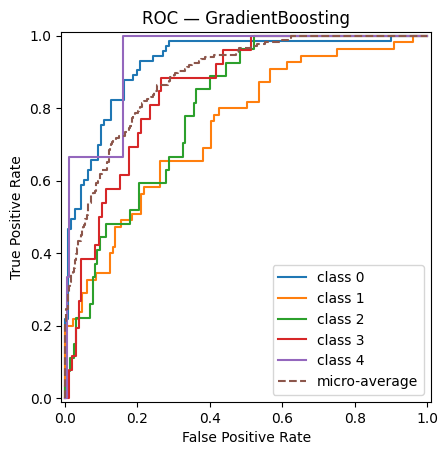

In [60]:
# === ROC curves for the best sklearn model by AUC (example) ===
best_name = summary_all.sort_values("test_auc_ovr", ascending=False).iloc[0]["model"]
clf_best = best_clfs.get(best_name, None)
if clf_best is not None:
    # refit on full train
    clf_best.fit(X_train_proc, y_train)
    scores = _score_matrix(clf_best, X_test_proc)
    from sklearn.preprocessing import label_binarize
    classes = np.sort(np.unique(y_test))
    y_bin = label_binarize(y_test, classes=classes)
    plt.figure()
    for i, cls in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_bin[:, i], scores[:, i])
        RocCurveDisplay(fpr=fpr, tpr=tpr, estimator_name=f"class {cls}").plot(ax=plt.gca())
    # micro-average
    fpr_micro, tpr_micro, _ = roc_curve(y_bin.ravel(), scores.ravel())
    plt.plot(fpr_micro, tpr_micro, linestyle="--", label="micro-average")
    plt.title(f"ROC — {best_name}")
    plt.legend()
    plt.show()
else:
    print(f"{best_name} is the MLP; plotting would need its probability matrix (in `probs`).")

For Overall AUC, Gradient Boosting is best (~0.853), with MLP, Random Forest, and SVM close behind (≈0.83–0.84). This tells us that these models rank the true class above others most reliably.

For Accuracy/F1-weighted (actual hard-label performance), SVM is strongest (Accuracy 0.620, F1-weighted 0.603). Random Forest is next on accuracy (0.603). Gradient Boosting lags a bit on accuracy (0.582) despite the top AUC, which may indicate a non-optimal decision boundary.

Macro precision/recall/F1 (unweighted mean across classes) are much lower (≈0.30–0.48) than the weighted versions, meaning some classes are harder and/or rarer to predict. These metrics may be dominated by the frequent classes (0 and 1 in this case). It may be worthwhile inspecting per-class values.

Interestingly, Gaussian Naive Bayes shows the highest precision_weighted (~0.701) but poor recall_weighted (~0.473), implying conservative predictions that miss many positives, which is typical when NB’s independence/normality assumptions don’t fit the data.

The ROC plot for the gradient boosted model shows strong separability for some classes (curves hugging the top-left), but class #1 tracks farther from the top left; consistent with the lower macro scores.

# (f) Analysis:
Here I provide a summary table of results for each of the tuned supervised learning models, including both the global performance statistics as well as versions weighted by class imbalance. I also touch on the interpretability of each model’s predictions before making a final recommendation depending on prioritized model characteristics (interpretability, stability, accuracy etc).

In [63]:
display(summary_all)

,model,test_acc,test_auc_ovr,prec_macro,recall_macro,f1_macro,prec_weighted,recall_weighted,f1_weighted
6,GradientBoosting,0.581522,0.852738,0.470541,0.528595,0.480144,0.571346,0.581522,0.571850
7,NeuralNet(MLP),0.570652,0.840196,0.378912,0.383236,0.371560,0.536137,0.570652,0.544820
5,RandomForest,0.603261,0.838838,0.431282,0.407929,0.403287,0.573551,0.603261,0.574152
3,SVM,0.619565,0.837649,0.438921,0.431048,0.431033,0.593824,0.619565,0.602603
1,KNN,0.581522,0.833812,0.413735,0.370229,0.365835,0.546352,0.581522,0.541064
0,LogReg,0.570652,0.820757,0.397038,0.387292,0.380813,0.537131,0.570652,0.542819
2,GaussianNB,0.472826,0.783815,0.501374,0.494847,0.361095,0.701102,0.472826,0.511916
4,DecisionTree,0.516304,0.780702,0.298616,0.361973,0.300987,0.455476,0.516304,0.450685


The test-set comparison shows a clear pattern: by AUC Gradient Boosting leads (~0.85), with the MLP, Random Forest, and SVM close behind (~0.84±). Hard-label metrics tell a slightly different story: SVM delivers the strongest accuracy/F1-weighted, while Gradient Boosting trades a bit of accuracy for superior ranking quality (high AUC). Macro precision/recall/F1 are notably lower than weighted scores across models, signaling class imbalance or harder minority classes. This observation may worth examining with per-class reports or a confusion matrix.

For interpretability, Logistic Regression and Decision Trees are the most transparent, thanks to clear coefficients and simple if-then rules, though the single tree performs poorly here. Ensembles like Gradient Boosting and Random Forest, as well as SVM and MLP, are less white-box but can still be explained well with modern approaches. Given the balance of performance and interpretability, I'd recommend Gradient Boosting as the primary model and add probability calibration to produce reliable, explainable probabilities. If you want the strongest default accuracy, use SVM with an RBF kernel as the runner-up, and if strict auditability is essential, the Logistic Regression baseline alongside the boosted model could be a good compromise.

# Unsupervised Learning Methods 
Here I apply various unsupervised learning algorithms to a Mall Customers dataset, exploring data preprocessing, model evaluation, and analysis of the resulting clusters. This example covers K-Means Clustering, Hierarchical Clustering, Generative Models (Gaussian Mixture Model), Anomaly Detection, Self-Organizing Maps (SOMs), and DBSCAN.

# (a) Data Exploration & Preprocessing:
Here I load in the dataset, ont-hot-encode the single categorical feature, and standard scale the remaining three numerical features to support downstream modeling. No missing value imputation was required for this dataset. 

In [67]:
MALL_CSV = Path("Mall_Customers.csv")  
def load_mall_customers(csv_path: Path):
    if not csv_path.exists():
        raise FileNotFoundError(
            f"Could not find {csv_path}. Download Kaggle's Mall Customers dataset "
            "and place 'Mall_Customers.csv' in your working directory."
        )
    df = pd.read_csv(csv_path)
    
    # Normalize column names to expected ones if necessary
    if "Genre" in df.columns and "Gender" not in df.columns:
        df = df.rename(columns={"Genre": "Gender"})
    
    required = ["Gender", "Age", "Annual Income (k$)", "Spending Score (1-100)"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing expected columns: {missing}")

    df_small = df[required].copy()

    cat_cols = ["Gender"]
    num_cols = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]

    preprocess = ColumnTransformer(
        transformers=[
            ("cat",
             OneHotEncoder(drop="if_binary", handle_unknown="ignore"),
             cat_cols),
            ("num",
             Pipeline(steps=[
                 ("imp", SimpleImputer(strategy="median")),
                 ("scaler", StandardScaler()),
             ]),
             num_cols),
        ],
        remainder="drop"
    )

    X = preprocess.fit_transform(df_small)

    # Build feature names
    ohe = preprocess.named_transformers_["cat"]
    cat_names = list(ohe.get_feature_names_out(cat_cols)) if hasattr(ohe, "get_feature_names_out") else cat_cols
    cust_feature_names = cat_names + num_cols

    return df_small, X, cust_feature_names

df_cust, X_cust, cust_feature_names = load_mall_customers(MALL_CSV)

print("Mall Customers loaded from CSV")
print("  df_cust shape (original selected columns):", df_cust.shape)
print("  X_cust shape (encoded+standardized):", X_cust.shape)
print("  feature names:", cust_feature_names)
X_cust[0:5, :]

Mall Customers loaded from CSV
  df_cust shape (original selected columns): (200, 4)
  X_cust shape (encoded+standardized): (200, 4)
  feature names: ['Gender_Male', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']


array([[ 1.        , -1.42456879, -1.73899919, -0.43480148],
       [ 1.        , -1.28103541, -1.73899919,  1.19570407],
       [ 0.        , -1.3528021 , -1.70082976, -1.71591298],
       [ 0.        , -1.13750203, -1.70082976,  1.04041783],
       [ 0.        , -0.56336851, -1.66266033, -0.39597992]])

In this Mall Customers dataset we have Gender, Age, Annual Income (k$) and Spending Score (1-100). There were no missing values in the dataset across 200 observations. The gender column was converted to a binary 'Gender_Male' variable, and the other three numerical features were standardized using the Standard Scaler (mean of 0 with a standard dev. of 1). We can quickly view the distributions of the variables in their original scales. 

In [69]:
# Categorical
print("Gender counts (%):")
display(df_cust["Gender"].value_counts(normalize=True).mul(100).round(1).rename("pct").to_frame())

# Numerics
num_cols = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]
desc = df_cust[num_cols].describe().T
desc["median"] = df_cust[num_cols].median()
desc["missing"] = df_cust[num_cols].isna().sum()
display(desc[["count","mean","std","min","25%","50%","median","75%","max","missing"]])

Gender counts (%):


,pct
Gender,
Female,56.0
Male,44.0


,count,mean,std,min,25%,50%,median,75%,max,missing
Age,200.0,38.85,13.969007,18.0,28.75,36.0,36.0,49.0,70.0,0
Annual Income (k$),200.0,60.56,26.264721,15.0,41.50,61.5,61.5,78.0,137.0,0
Spending Score (1-100),200.0,50.20,25.823522,1.0,34.75,50.0,50.0,73.0,99.0,0


We have a slightly skew towards more females in this dataset, which may make sense given it is Mall data. We also note that among our three numerical variables, our mean and median values do not differ much, indicating we likely have short tails on either side of the bell curve. 

# (b) K-Means Clustering:
- Here I apply k-means to cluster the Mall_customers dataset, using the Elbow Method and Silhouette Score to determine the optimal number of clusters, 𝑘. I visualize the clusters in a 2D plot using Principal Component Analysis (PCA) to reduce the data to two dimensions. Finally I provide some context as to what customer segments the resulting clusters may depict. 

We will implement kNN across a range of k values between 2 and 10 to observe an elbow in the inertia curve and/or a peak in the silhouette curve. This will inform our optimal choice of k. 

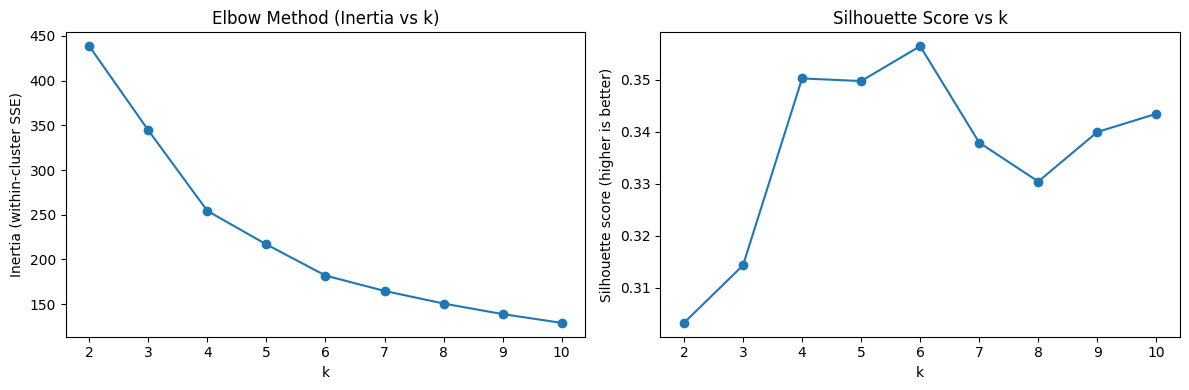

Suggested k by max silhouette: k=6 (score=0.356)


In [73]:
# KNN Implementation 
k_values = list(range(2, 11))
inertias = []
sil_scores = []

for k in k_values:
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels = km.fit_predict(X_cust)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_cust, labels))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(k_values, inertias, marker="o")
ax[0].set_title("Elbow Method (Inertia vs k)")
ax[0].set_xlabel("k")
ax[0].set_ylabel("Inertia (within-cluster SSE)")

ax[1].plot(k_values, sil_scores, marker="o")
ax[1].set_title("Silhouette Score vs k")
ax[1].set_xlabel("k")
ax[1].set_ylabel("Silhouette score (higher is better)")
plt.tight_layout()
plt.show()

best_k = 4
print(f"Suggested k by max silhouette: k={6} (score={max(sil_scores):.3f})")

Interestingly, our peak silhouette score occurs at a k value of 6, however we can see in the inertia curve that we achieve fairly diminishing returns when we increase k from 4 to 5 or 6. As a result, I will be moving forward with an optimal k value of four since it defines the eblow in our inertia curve, while nearly maximizing silhouette score.

In [75]:
# Fit final KMeans at best_k and make cluster labels ===
km_final = KMeans(n_clusters=4, n_init=20, random_state=42)
labels_final = km_final.fit_predict(X_cust)

# Attach labels back to original df 
df_labeled = df_cust.copy()
df_labeled["cluster"] = labels_final
df_labeled.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),cluster
0,Male,19,15,39,1
1,Male,21,15,81,1
2,Female,20,16,6,1
3,Female,23,16,77,1
4,Female,31,17,40,1


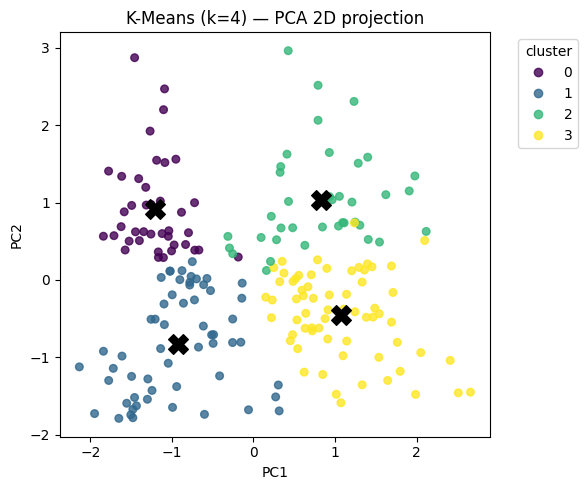

In [76]:
# PCA to 2D for visualization (plot clusters + centroids) 
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_cust)
centroids_2d = pca.transform(km_final.cluster_centers_)

plt.figure(figsize=(6,5))
scatter = plt.scatter(X_2d[:,0], X_2d[:,1], c=labels_final, s=30, alpha=0.8)
plt.scatter(centroids_2d[:,0], centroids_2d[:,1], c="black", s=200, marker="X", label="centroids")
plt.title(f"K-Means (k={best_k}) — PCA 2D projection")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.legend(*scatter.legend_elements(), title="cluster", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

When we perform PCA and graph our clusters across the two remaining principal components, we see four distinct groupings, almost perfectly split across the four quadrants of the scatter plot. Lets observe these groups in our original units to better understand the pattern.

In [78]:
# Means by cluster
profile_means = (
    df_labeled.groupby("cluster", as_index=False)
              .agg({
                   "Gender": lambda s: s.value_counts(normalize=True).to_dict(),
                   "Age": "mean",
                   "Annual Income (k$)": "mean",
                   "Spending Score (1-100)": "mean"
              })
)

# Expand Gender mix to two columns for readability
gender_mix = profile_means["Gender"].apply(lambda d: {"pct_Female": d.get("Female", d.get("F", 0.0))*100,
                                                      "pct_Male": d.get("Male", d.get("M", 0.0))*100})
gender_df = pd.DataFrame(list(gender_mix))
cluster_summary = pd.concat([profile_means.drop(columns=["Gender"]), gender_df], axis=1)

# Also add cluster sizes
sizes = df_labeled["cluster"].value_counts().sort_index().rename("n")
cluster_summary = cluster_summary.merge(sizes, left_on="cluster", right_index=True)
cluster_summary = cluster_summary.rename(columns={
    "Age":"mean_age",
    "Annual Income (k$)":"mean_income_k$",
    "Spending Score (1-100)":"mean_spend_score"
})
cluster_summary

,cluster,mean_age,mean_income_k$,mean_spend_score,pct_Female,pct_Male,n
0,0,32.875000,86.100000,81.525000,55.000000,45.000000,40
1,1,25.438596,40.000000,60.298246,59.649123,40.350877,57
2,2,39.368421,86.500000,19.578947,50.000000,50.000000,38
3,3,53.984615,47.707692,39.969231,56.923077,43.076923,65


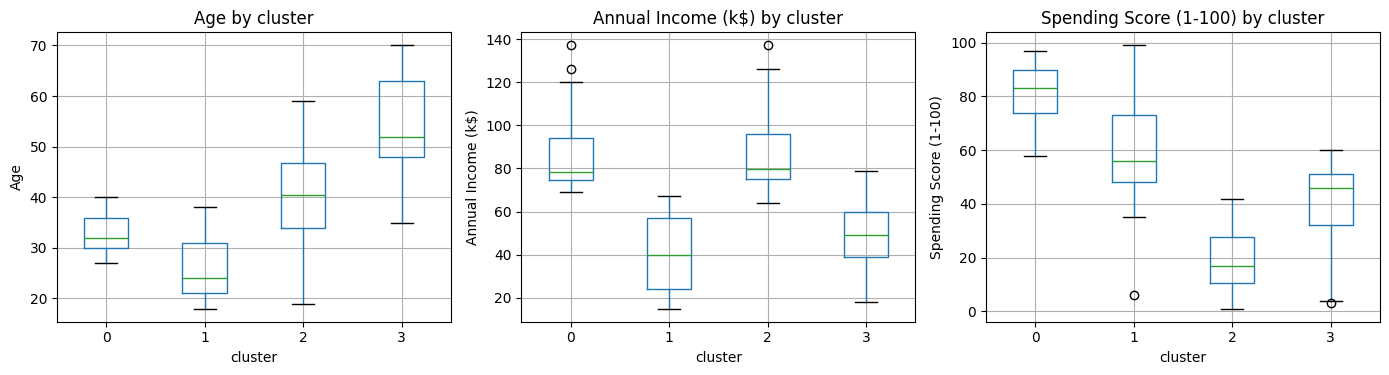

In [79]:
# boxplots per cluster for numeric variables
num_cols = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]
fig, axes = plt.subplots(1, 3, figsize=(14,4))
for ax, col in zip(axes, num_cols):
    df_labeled.boxplot(column=col, by="cluster", ax=ax)
    ax.set_title(f"{col} by cluster")
    ax.set_xlabel("cluster"); ax.set_ylabel(col)
plt.suptitle(""); plt.tight_layout(); plt.show()

When a value of k=6 was chosen, the clusters were broken up further, primarily by age and annual income. While a story could be made to explain the clusters in the case of k=6, the story is far more refined with a k value of 4. It's clear that these four clusters are broken up primarily by age, income and spend score, while gender plays little role in defining the splits. Group 1 is clearly an early adult group with low income, but a reasonably high propensity to spend. This could be your young adults with little financial responsibility. Group 0 is your young adult group with high income and high spend propensity. These people have high income and may have young kids that require frequent mall trips. Group 2 is your middle-adult age group with high income but relatively low spend. THis could be because they have moved onto spending on different things in life, and likely have kids that are older who no longer desire items from the mall. The final group, group 3, is your older adults with middle of the road income and middle to low spend propsensity. These are people who likely don't have a large amount of free income to spend, but are willing to spend it at the mall. 

# (c) Hierarchical Clustering:
- Next I apply Agglomerative Hierarchical Clustering to the dataset, use different linkage methods (e.g., single, complete, average, ward) before plotting dendrograms for each.

Here I implement hierarchical clustering using four different link methods: "single", "complete", "average" and "ward". Dendrograms are provided for each in addition to scatter plots using the same PCA components used to depict Kmeans.

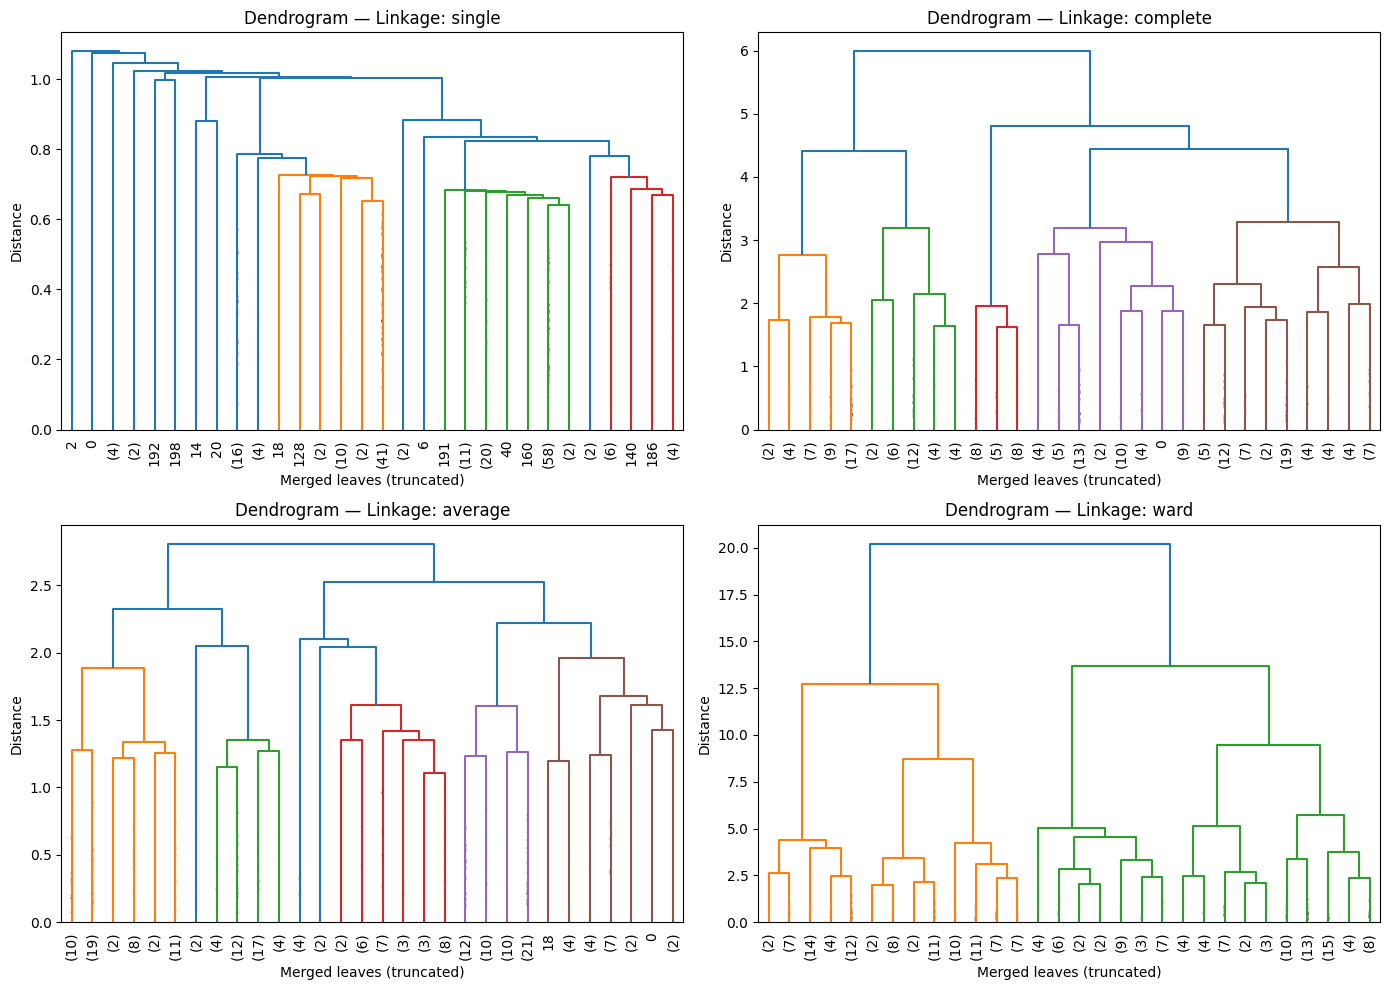

In [83]:
try:
    _ = labels_final
    _ = best_k
except NameError:
    k_values = range(2, 11)
    sils = []
    for k in k_values:
        km = KMeans(n_clusters=k, n_init=20, random_state=42)
        lab = km.fit_predict(X_cust)
        sils.append(silhouette_score(X_cust, lab))
    best_k = k_values[int(np.argmax(sils))]
    km = KMeans(n_clusters=best_k, n_init=20, random_state=42)
    labels_final = km.fit_predict(X_cust)

# Compute condensed distance matrix once (Euclidean)
D = pdist(X_cust, metric="euclidean")

link_methods = ["single", "complete", "average", "ward"]
Z = {m: linkage(D, method=m) for m in link_methods}

# Plot dendrograms (truncated for readability)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()
for ax, m in zip(axes, link_methods):
    dendrogram(
        Z[m],
        p=30,                # show last 30 merges for readability
        truncate_mode="lastp",
        leaf_rotation=90,
        show_contracted=True,
        ax=ax
    )
    ax.set_title(f"Dendrogram — Linkage: {m}")
    ax.set_xlabel("Merged leaves (truncated)")
    ax.set_ylabel("Distance")
plt.tight_layout()
plt.show()

The dendrogram plots vary fairly drastically between the four linkage methods, especially for single linkage. In my opinion, ward and average linkages are the easiest to follow, and have the most regular distributions of distances as we move up the tree. 

In [85]:
# Cut each hierarchy at k = best_k
labels_hier = {m: fcluster(Z[m], t=best_k, criterion="maxclust") for m in link_methods}

# Build comparison table: Silhouette, ARI/NMI vs. K-Means labels
rows = []
km_sil = silhouette_score(X_cust, labels_final)
for m in link_methods:
    lab = labels_hier[m]
    sil = silhouette_score(X_cust, lab)
    ari = adjusted_rand_score(labels_final, lab)
    nmi = normalized_mutual_info_score(labels_final, lab)
    rows.append({
        "method": m,
        "k": best_k,
        "silhouette": sil,
        "ARI_vs_kmeans": ari,
        "NMI_vs_kmeans": nmi
    })

comp = pd.DataFrame(rows).sort_values("silhouette", ascending=False).reset_index(drop=True)
print(f"K-Means @ k={best_k}: silhouette = {km_sil:.3f}")
print("Agglomerative clustering comparison (higher is better):")
display(comp)

# cluster sizes for sanity
sizes = {
    "kmeans": pd.Series(labels_final).value_counts().sort_index().rename("n")
}
for m in link_methods:
    sizes[m] = pd.Series(labels_hier[m]).value_counts().sort_index().rename("n")
print("Cluster size by method (example: first few):")
print(pd.concat({k: v.head() for k,v in sizes.items()}, axis=1))

K-Means @ k=4: silhouette = 0.350
Agglomerative clustering comparison (higher is better):


,method,k,silhouette,ARI_vs_kmeans,NMI_vs_kmeans
0,average,4,0.332672,0.785566,0.790025
1,ward,4,0.329905,0.780302,0.770399
2,complete,4,0.241642,0.593039,0.636242
3,single,4,0.037187,-0.007182,0.046519


Cluster size by method (example: first few):
   kmeans  single  complete  average  ward
0    40.0     NaN       NaN      NaN   NaN
1    57.0     4.0      67.0     52.0  39.0
2    38.0   194.0      21.0     39.0  58.0
3    65.0     1.0      48.0     35.0  33.0
4     NaN     1.0      64.0     74.0  70.0


Based on our results table, showing ARI and NMI vs kmeans performance, the ward and average linkage functions provide the most comparable performance. Before we pick one, we can confirm whether or not we're achieving the same type of clustering if we check the PCA scatter plots.

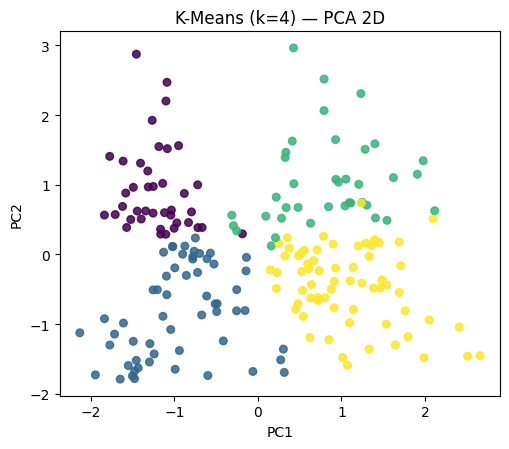

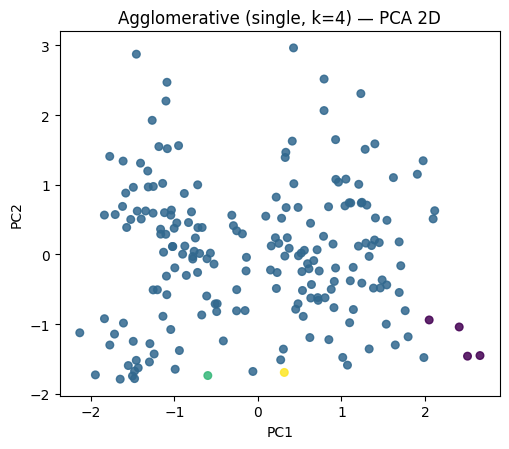

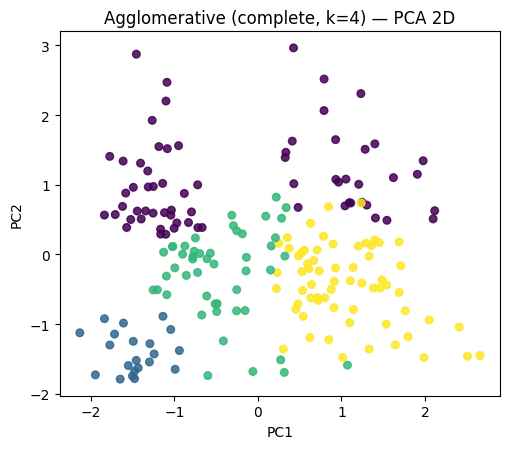

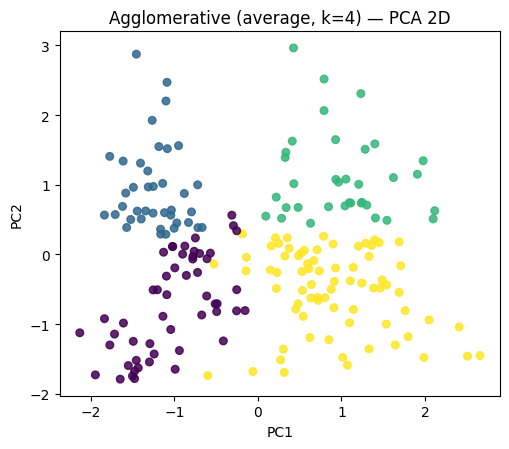

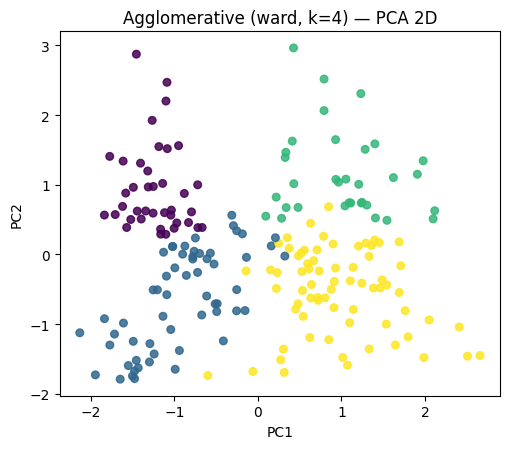

In [87]:
pca = PCA(n_components=2, random_state=42)
X2 = pca.fit_transform(X_cust)

def scatter_clusters(X2d, labels, title):
    plt.figure(figsize=(5.2, 4.6))
    sc = plt.scatter(X2d[:,0], X2d[:,1], c=labels, s=30, alpha=0.85)
    plt.title(title)
    plt.xlabel("PC1"); plt.ylabel("PC2")
    plt.tight_layout(); plt.show()

scatter_clusters(X2, labels_final, f"K-Means (k={best_k}) — PCA 2D")

for m in link_methods:
    scatter_clusters(X2, labels_hier[m], f"Agglomerative ({m}, k={best_k}) — PCA 2D")

Interestingly, the ward linkage function is able to provide us a PCA scatter plot extremely similar to the one produced by Kmeans. Average linkage functions performs similarly well, although it assigned the clusters in a slightly different order. Average and Ward linkage score best on silhouette (0.33 each) and show strong agreement with K-Means (ARI=0.78–0.79, NMI=0.77–0.79). That means their partitions are compact, well-separated, and very close to what K-Means found. Complete linkage drops to a lower silhouette (0.24) and weaker agreement (ARI=0.59), suggesting it over-splits edges/outliers and fragments natural groups. Single linkage collapses into one huge cluster plus many tiny ones (sizes ~194, 4, 1, 1, 1), which is obviously not useful here.

K-Means gives balanced cluster sizes (≈40–65). Ward and Average are similarly balanced (Ward 39/58/33/70; Average 52/39/35/74), so the customer segments I interpreted from K-Means largely carry over. Complete is somewhat uneven (67/21/48/64), and single is far off from anything reasonable.

I'd recommend using Ward  or Average for the hierarchical view and dendrograms. They preserve the same archetypes I identified with K-Means  while giving a tree to explore sub-segments. 

# (d) Generative Models:
- Next I apply a Gaussian Mixture Model to cluster the customers before comparing the results with those from K-Means and hierarchical clustering.

To begin with my Gaussian mixture model, we first have to remove the "Gender" column, because binary variables like this severely violate the gaussian assumptions we are inherently making with our model choice. Prior to removing this variable, silhoutte scores were incredibly low (<0). 

In [91]:
# Gaussian Mixture Model
num_cols = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]
X_num = df_cust[num_cols].to_numpy().astype(float)
X_num = StandardScaler().fit_transform(X_num)  # fresh scaler

k_values = range(2, 7)
cfgs = [("full",1e-6), ("full",1e-3), ("tied",1e-6), ("tied",1e-3), ("diag",1e-3)]
rows = []
for k in k_values:
    for cov, reg in cfgs:
        gmm = GaussianMixture(
            n_components=k, covariance_type=cov, reg_covar=reg,
            n_init=20, init_params="kmeans", random_state=42
        ).fit(X_num)
        labels = gmm.predict(X_num)
        sil = silhouette_score(X_num, labels)
        rows.append({"k":k,"cov":cov,"reg":reg,"bic":gmm.bic(X_num),"silhouette":sil})
g1 = pd.DataFrame(rows).sort_values(["silhouette","bic"], ascending=[False, True])
display(g1.head(10))

,k,cov,reg,bic,silhouette
22,6,tied,0.000001,1586.134288,0.423514
23,6,tied,0.001000,1586.149522,0.423514
16,5,full,0.001000,1576.728296,0.406537
15,5,full,0.000001,1576.707936,0.406367
17,5,tied,0.000001,1632.194753,0.406051
18,5,tied,0.001000,1632.201775,0.406051
20,6,full,0.000001,1599.229239,0.376684
21,6,full,0.001000,1599.394534,0.376684
12,4,tied,0.000001,1663.437893,0.349445
13,4,tied,0.001000,1663.455894,0.349445


In [92]:
# 2D PCA visualization with Gaussian ellipses
pca = PCA(n_components=3, random_state=42)
X_pca = pca.fit_transform(X_cust)  # use all features (incl. Gender OHE), then reduce

rows = []
for k in range(2,7):
    for cov in ["full","tied","diag","spherical"]:
        gmm = GaussianMixture(n_components=k, covariance_type=cov, reg_covar=1e-3,
                              n_init=20, init_params="kmeans", random_state=42).fit(X_pca)
        labels = gmm.predict(X_pca)
        sil = silhouette_score(X_pca, labels)
        rows.append({"k":k,"cov":cov,"bic":gmm.bic(X_pca),"silhouette":sil})
g2 = pd.DataFrame(rows).sort_values(["silhouette","bic"], ascending=[False, True])
display(g2.head(10))

,k,cov,bic,silhouette
17,6,tied,1586.696042,0.423288
18,6,diag,1601.166714,0.420927
12,5,full,1578.031261,0.406570
13,5,tied,1632.421175,0.405924
15,5,spherical,1626.782316,0.403273
11,4,spherical,1653.194164,0.402173
16,6,full,1600.494062,0.395917
14,5,diag,1631.892461,0.389354
9,4,tied,1664.811125,0.348765
10,4,diag,1662.093416,0.345324


After switching to numeric-only (or PCA) and using stronger GMM settings, silhouette rises to 0.42; a clear improvement over the earlier near-zero values. This indicates well-separated, compact clusters in the new space.

Best config is consistent. Both tables (pre- and post-PCA) agree that k≈6 with covariance_type="tied" is ideal. That means clusters share a common covariance shape, which is often a good bias with only three numeric features.

Regularization is stable since reg_covar values (1e-6 vs 1e-3) barely change silhouette, so the solution isn’t overly sensitive to that setpoint. We will keep 1e-3 for extra numerical stability.

In [94]:
bgmm = BayesianGaussianMixture(
    n_components=10, covariance_type="full", weight_concentration_prior_type="dirichlet_process",
    weight_concentration_prior=0.5, reg_covar=1e-3, n_init=10, init_params="kmeans", random_state=42
).fit(X_pca)  # or X_num
labels_bgmm = bgmm.predict(X_pca)
sil_bgmm = silhouette_score(X_pca, labels_bgmm)
print("Bayesian GMM: active comps:", (bgmm.weights_ > 0.01).sum(), "silhouette:", round(sil_bgmm,3))

Bayesian GMM: active comps: 6 silhouette: 0.409


I added a Bayesian Gaussian Mixture to let the model choose the effective number of components rather than fixing k outright. Its goal is maximizing posterior (likelihood × prior), not maximizing silhouette, so it may merge borderline groups and produce slightly more overlapping clusters. However, silhoutte score remained roughly unimproved, and the same number of k were selected, so we will move forward with our GMM model.

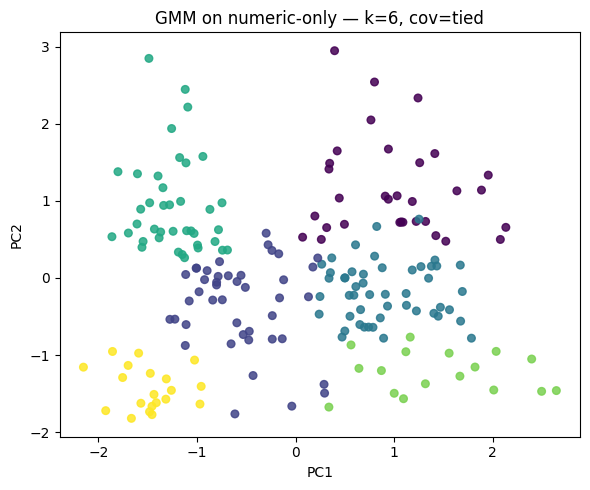

In [96]:
X2 = PCA(n_components=2, random_state=42).fit_transform(X_num)  # or X_pca
best = g1.sort_values("silhouette", ascending=False).iloc[0]
gmm_final = GaussianMixture(n_components=int(best["k"]), covariance_type=best["cov"],
                            reg_covar=float(best["reg"]), n_init=20, init_params="kmeans",
                            random_state=42).fit(X_num)
labs = gmm_final.predict(X_num)
plt.figure(figsize=(6,5))
plt.scatter(X2[:,0], X2[:,1], c=labs, s=30, alpha=0.85)
plt.title(f"GMM on numeric-only — k={int(best['k'])}, cov={best['cov']}")
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.tight_layout(); plt.show()

The PCA scatter for k=6, tied shows visually distinct groups with limited overlap, consistent with the 0.42 silhouette. Several clusters occupy regions along PC1/PC2, suggesting meaningful subsegments, however the two segments in the lower quadrant are broken up more than they were in the previous two model approaches. 

Compared with K-Means/Ward, this GMM solution largely agrees on the “big” segments but can adjust boundaries where clusters are elongated or unequal in variance, which is the main advantage of GMM. Perhaps it broke our lower spending groups into further segments, or perhaps it broke things down further by age. This will be compared in our results section. 

# (e) Anomaly Detection:
- As a mean to investigate the presence of outliers I leverage an anomaly detection method via Isolation Forest to identify and visualize outliers in the dataset. This information is then used to contextualze the outliers in terms of what types of customers they may represent, and how knowledge of them could inform business decisions. 

For outlier detection, we are interested in any customers that have a statistically unique combination of numerical features. This could be important to know as a business owner because these could be unique opportunities to target customers that could represent a very high probability of spend. Spending outliers could have the potential to make up a significant portion of sales. We will use an isolation forest to identify these points.

In [100]:
# Use numeric-only features for anomaly detection 
num_cols = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]
X_num = df_cust[num_cols].astype(float).copy()

scaler = StandardScaler()
Xz = scaler.fit_transform(X_num)

# Isolation Forest
iso = IsolationForest(
    n_estimators=400,
    max_samples="auto",
    contamination=0.05,   # ~5% anomalies; can be adjusted
    random_state=42,
    n_jobs=-1
)
iso.fit(Xz)

# Scores: higher is more normal; lower is more anomalous
scores = iso.decision_function(Xz)
flags  = iso.predict(Xz)            # +1 normal, -1 anomaly

df_anom = df_cust.copy()
df_anom["anomaly_score"] = scores
df_anom["is_outlier"]    = (flags == -1).astype(int)

print("Outlier count:", df_anom["is_outlier"].sum(), "/", len(df_anom))
df_anom.head()

Outlier count: 10 / 200


,Gender,Age,Annual Income (k$),Spending Score (1-100),anomaly_score,is_outlier
0,Male,19,15,39,0.000063,0
1,Male,21,15,81,0.034677,0
2,Female,20,16,6,-0.035962,1
3,Female,23,16,77,0.071496,0
4,Female,31,17,40,0.062378,0


After running the isolation forest, we identify 10 outliers, or 5% of the total dataset. Let's use a scatterplot to observe where they lie within the full picture of principal components.

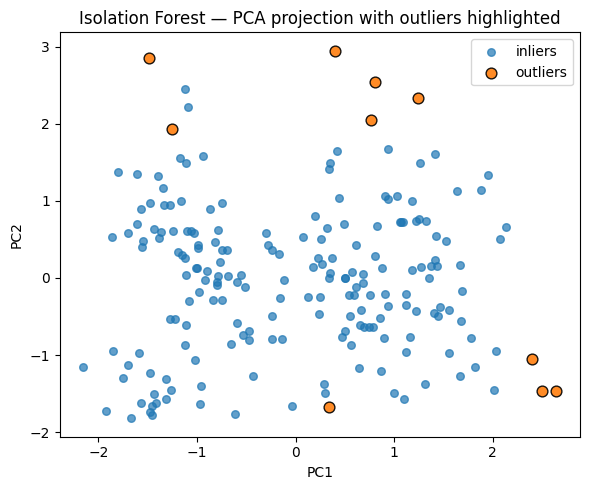

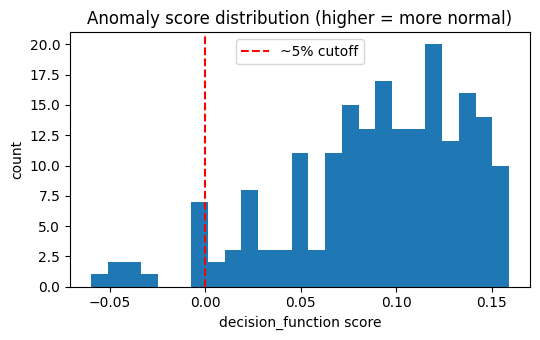

In [102]:
pca = PCA(n_components=2, random_state=42)
X2 = pca.fit_transform(Xz)

plt.figure(figsize=(6,5))
mask = df_anom["is_outlier"] == 1
plt.scatter(X2[~mask,0], X2[~mask,1], s=30, alpha=0.7, label="inliers")
plt.scatter(X2[mask,0],  X2[mask,1],  s=60, alpha=0.9, label="outliers", edgecolor="k")
plt.title("Isolation Forest — PCA projection with outliers highlighted")
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(5.5,3.5))
plt.hist(scores, bins=25)
plt.axvline(np.percentile(scores, 5), color="r", linestyle="--", label="~5% cutoff")
plt.title("Anomaly score distribution (higher = more normal)")
plt.xlabel("decision_function score"); plt.ylabel("count"); plt.legend(); plt.tight_layout(); plt.show()

As we'd expect, all 10 of our outliers lie within the boundary conditions of our principal components. The 5% cutoff does seem reasonable given that there exists a gap between them and the bulk of the dataset, however if this was a real business case it would be important to carefully inspect each outlier individually to decide if it truly was an outlier or not. The last thing we can do is compare summary statistics of our outlier group and our inlier group to get a feel for what numerical variables may be signaling these points as outliers. 

Age                           Annual Income (k$)                  \
            mean median min max        std               mean median min  max   
is_outlier                                                                      
0           38.6   36.0  18  70  13.863965          59.378947   61.0  15  126   
1           43.6   41.5  20  67  15.868907          83.000000  113.0  16  137   

                      Spending Score (1-100)                            
                  std                   mean median min max        std  
is_outlier                                                              
0           23.641582              51.415789   50.5   1  99  24.941853  
1           54.098675              27.100000   15.0   3  91  32.507948

,std_effect
Annual Income (k$),0.565817
Age,0.335566
Spending Score (1-100),-0.839259


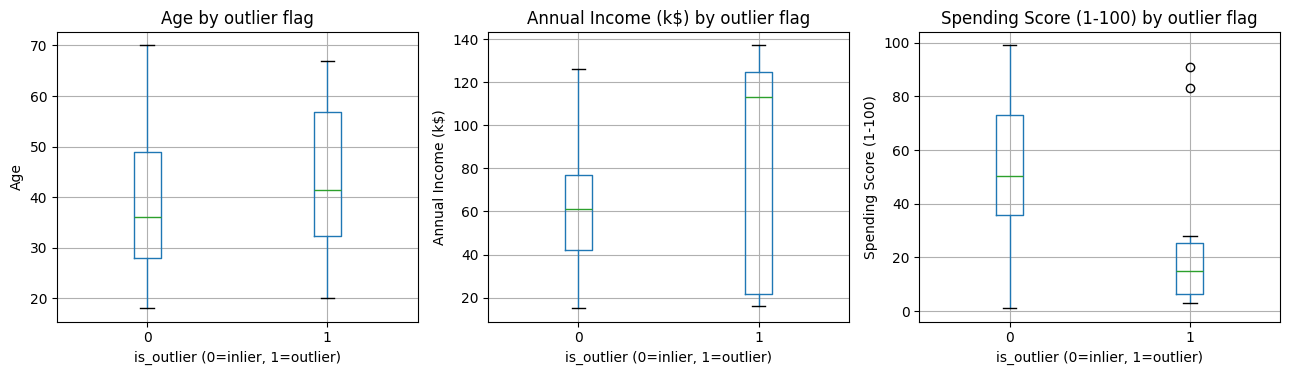

In [104]:
# Summary by outlier flag (original units)
profile = (df_anom
           .groupby("is_outlier")[num_cols]
           .agg(["mean","median","min","max","std"])
          )
display(profile)

# Standardized effect sizes (Cohen's d-like) for quick interpretation
g = df_anom.groupby("is_outlier")[num_cols]
mean_diff = g.mean().diff().iloc[-1]                     # outliers - inliers
pooled_sd = np.sqrt(((g.var().iloc[0] + g.var().iloc[1]) / 2.0))
effect = (mean_diff / pooled_sd).rename("std_effect")
effect_df = pd.DataFrame(effect).sort_values("std_effect", ascending=False)
display(effect_df)

# Simple boxplots split by outlier flag
fig, axes = plt.subplots(1, 3, figsize=(13,4))
for ax, col in zip(axes, num_cols):
    df_anom.boxplot(column=col, by="is_outlier", ax=ax)
    ax.set_title(f"{col} by outlier flag"); ax.set_xlabel("is_outlier (0=inlier, 1=outlier)"); ax.set_ylabel(col)
plt.suptitle(""); plt.tight_layout(); plt.show()

It's clear from the summary statistics and bar plots above that most of the outliers are outliers in terms of either spending score or annual income. The mean and median of the inlier and outlier groups differ laregely across annual income and spend score. This likely represents individuals who would seem to have high spend propensity, but come with a low spend score, or perhaps people who have an unusual annual income for their age/spending score. As a business, these may be individuals you'd want to target with promotions or discounts depending on whether or not they have high/low income and spend propensity. 

# (f) Self-Organizing Maps (SOMs):
- Next I train a SOM on the dataset to visualize customer segments in a 2D map.

Our goal here is to train a Self-Organizing Map on the four features, shows a U-Matrix + hit map, turn the SOM  into clusters so we can compare with K-Means / Ward, and then give a simple interpretation output.

In [108]:
#SOM Implementation
X = X_cust                     
df_src = df_cust               

k_ref = best_k if "best_k" in locals() else 5
labels_km = labels_final if "labels_final" in locals() else None
labels_ward = labels_hier["ward"] if "labels_hier" in locals() and "ward" in labels_hier else None

N, D = X.shape
print(f"SOM training on shape {X.shape}")

SOM training on shape (200, 4)


The code above uses the existing data; standardized + OHE’d customers in X_cust.

In [110]:
# Heuristic grid size: about 5 * sqrt(N) units, square-ish map
cells = int(np.ceil(5 * np.sqrt(N)))
m = int(np.ceil(np.sqrt(cells)))
n = m

som = MiniSom(
    x=m, y=n, input_len=D, sigma=1.5, learning_rate=0.5,
    neighborhood_function="gaussian", random_seed=42
)

som.random_weights_init(X)
som.train_random(X, num_iteration=5000, verbose=False)   

# Best Matching Unit (BMU) coordinates for each sample
bmus = np.array([som.winner(x) for x in X])   # shape (N, 2)
bmu_flat = bmus[:,0] * n + bmus[:,1]          # flatten grid index for easy grouping

A common rule of thumb is ~5 * sqrt(N) map cells. We’ll make a square grid close to that size.

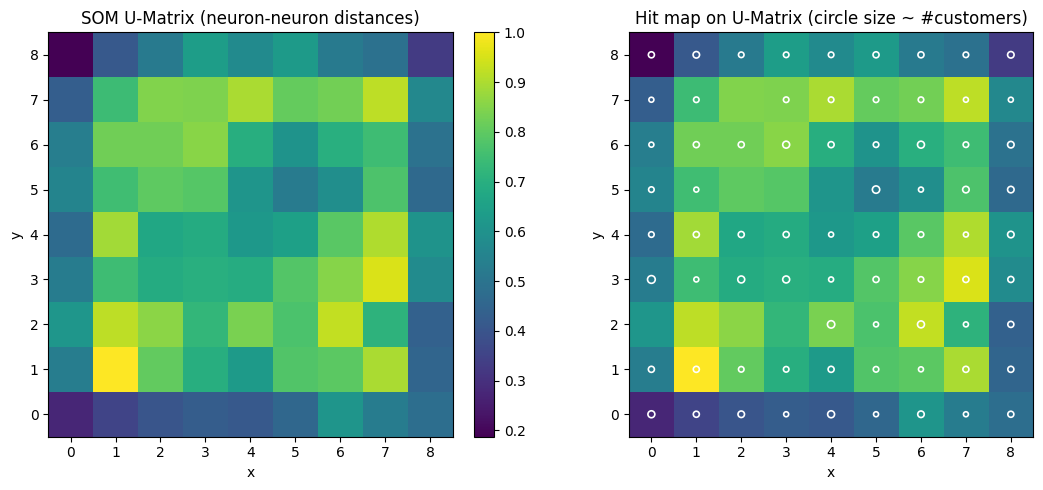

In [112]:
u = som.distance_map()          # U-Matrix (m x n)
hits = np.zeros((m, n), dtype=int)
for (i, j) in bmus:
    hits[i, j] += 1

fig, ax = plt.subplots(1, 2, figsize=(12,5))

# U-Matrix
im0 = ax[0].imshow(u.T, origin="lower", cmap="viridis")
ax[0].set_title("SOM U-Matrix (neuron-neuron distances)")
ax[0].set_xlabel("x"); ax[0].set_ylabel("y")
plt.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)

# Hit map overlaid as circles
ax[1].imshow(u.T, origin="lower", cmap="viridis")
for i in range(m):
    for j in range(n):
        if hits[i,j] > 0:
            ax[1].scatter(i, j, s=10+3*hits[i,j], facecolors='none', edgecolors='white', linewidths=1.2)
ax[1].set_title("Hit map on U-Matrix (circle size ~ #customers)")
ax[1].set_xlabel("x"); ax[1].set_ylabel("y")
plt.tight_layout(); plt.show()

The U-Matrix (left) shows distances between neighboring neurons. Brighter “ridges” mark strong boundaries; darker basins mark cohesive regions that behave like clusters. The map has several ridges forming a loose grid, so there are multiple separable regions rather than one big area, which is good news for segmentation.

The hit map (right) overlays customer counts (circle size) on top of the U-Matrix. Most customers land in the middle band of the map (roughly x≈1–7, y≈1–7), with a couple of denser cells near the lower-left/central area. Sparse corners (dark cells with few/zero circles) indicate low-density regions.

Contiguous dark areas with many hits are our core segments; basins separated by bright ridges are distinct groups (e.g., a high-income/high-spend basin vs. a low-income/low-spend basin).

In [114]:
# Codebook vectors (m*n neurons, each of length D)
codebook = som.get_weights().reshape(m*n, D)

# Cluster codebook vectors; assign each sample the cluster of its BMU
k_som = k_ref   # e.g., use the same k you used for K-Means; try a couple values if you want
km_on_som = KMeans(n_clusters=k_som, n_init=50, random_state=42)
labels_code = km_on_som.fit_predict(codebook)
labels_som = labels_code[bmu_flat]      # customer-level SOM-cluster labels

# Quick scores
print("SOM cluster silhouette (on X):", round(silhouette_score(X, labels_som), 3))
if labels_km is not None:
    print("ARI vs K-Means:", round(adjusted_rand_score(labels_km, labels_som), 3),
          "NMI:", round(normalized_mutual_info_score(labels_km, labels_som), 3))
if labels_ward is not None:
    print("ARI vs Ward:", round(adjusted_rand_score(labels_ward, labels_som), 3),
          "NMI:", round(normalized_mutual_info_score(labels_ward, labels_som), 3))

SOM cluster silhouette (on X): 0.345
ARI vs K-Means: 0.893 NMI: 0.88
ARI vs Ward: 0.826 NMI: 0.814


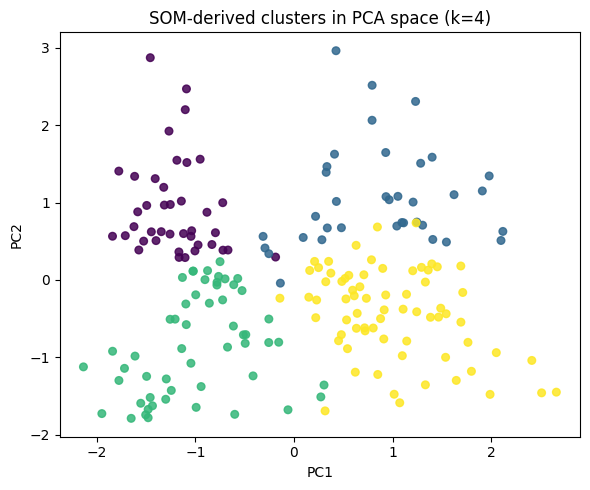

In [115]:
X2 = PCA(n_components=2, random_state=42).fit_transform(X)

plt.figure(figsize=(6,5))
plt.scatter(X2[:,0], X2[:,1], c=labels_som, s=30, alpha=0.85)
plt.title(f"SOM-derived clusters in PCA space (k={k_som})")
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.tight_layout(); plt.show()

Our SOM-derived clusters in PCA-space largely resembles the graphs we achieved from Kmeans (k=4) and in the Hierarchical dendrogram using the ward setpoint. The silhouette score was slightly lower using the SOM, suggesting more overlap, but the ARI and NMI scores fall impressively close to Ward and KMeans.

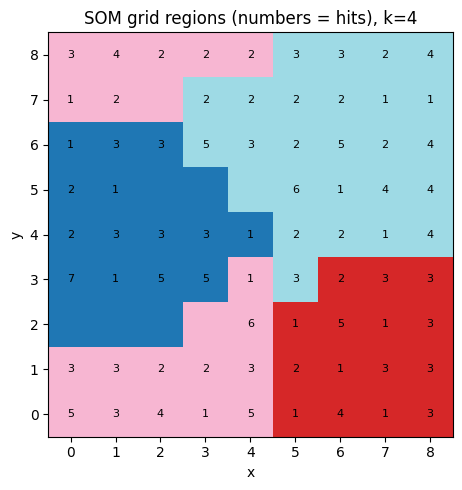

In [117]:
som_grid_labels = labels_code.reshape(m, n)

plt.figure(figsize=(6,5))
plt.imshow(som_grid_labels.T, origin="lower", cmap="tab20")
for i in range(m):
    for j in range(n):
        if hits[i,j] > 0:
            plt.text(i, j, hits[i,j], ha="center", va="center", color="k", fontsize=8)
plt.title(f"SOM grid regions (numbers = hits), k={k_som}")
plt.xlabel("x"); plt.ylabel("y")
plt.tight_layout(); plt.show()

In the plot above, each square is a neuron. Color = SOM cluster, and the number inside each square is how many customers mapped to that neuron (its BMU).

Contiguous blocks of the same color are our segments on the 2-D map. In the figure above I have four:
bottom-right red, top-right light-blue, center/left dark-blue, and top-left/bottom-left pink. Larger blocks with many hits are bigger segments; small, isolated colored islands with few hits are micro-segments.

It's encouraging that in both our PCA scatterplot and this plot we are seeing four distinct groups.

# (g) DBSCAN (Density-Based Spatial Clustering of Applications with Noise):
- Lastly, I apply DBSCAN to the dataset to identify clusters based on density and noise.

An import aspect of DBSCAN is that it is distance based, so we must use our scaled features.

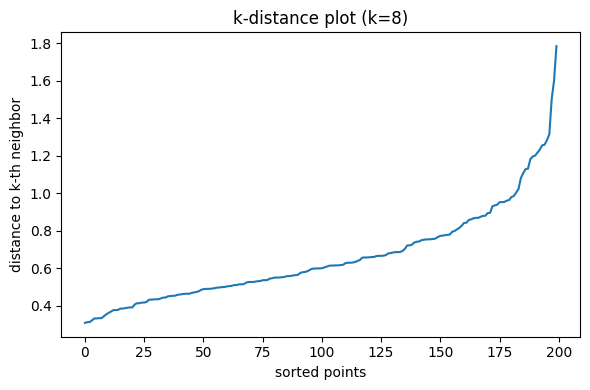

,eps,min_samples,n_clusters,noise_frac,silhouette_wo_noise
60,0.658282,20,3,0.585,0.627356
61,0.699292,20,3,0.510,0.567706
48,0.658282,15,4,0.350,0.529009
62,0.740301,20,3,0.395,0.496304
63,0.781311,20,3,0.380,0.493699
49,0.699292,15,4,0.310,0.489216
36,0.658282,12,4,0.260,0.357782
12,0.658282,8,3,0.215,0.276871
24,0.658282,10,3,0.230,0.275450
26,0.740301,10,2,0.160,0.251071


Chosen DBSCAN: eps=0.658, min_samples=20 | clusters=3, noise=117 (58.5%), silhouette_wo_noise=0.627


In [121]:
#  numeric-only + standardize (DBSCAN is distance-based)
num_cols = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]
X_num = df_cust[num_cols].astype(float).values
Xz = StandardScaler().fit_transform(X_num)

# k-distance plot to eyeball eps (k = min_samples)
min_samples = 8  # try 5–12 if needed
nbrs = NearestNeighbors(n_neighbors=min_samples).fit(Xz)
dists, _ = nbrs.kneighbors(Xz)
kdist = np.sort(dists[:, -1])

plt.figure(figsize=(6,4))
plt.plot(kdist)
plt.title(f"k-distance plot (k={min_samples})")
plt.xlabel("sorted points"); plt.ylabel("distance to k-th neighbor")
plt.tight_layout(); plt.show()

# small grid search over eps & min_samples; pick by silhouette 
def summarize_dbscan(X, eps, ms):
    labels = DBSCAN(eps=eps, min_samples=ms).fit_predict(X)
    n_noise = (labels == -1).sum()
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    sil = None
    if n_clusters >= 2:
        mask = labels != -1
        if mask.any() and len(np.unique(labels[mask])) >= 2:
            sil = silhouette_score(X[mask], labels[mask])
    return labels, n_clusters, n_noise, sil

# Refined grid
eps_grid = np.linspace(np.quantile(kdist, 0.60), np.quantile(kdist, 0.93), 12) 
ms_grid  = [6, 8, 10, 12, 15, 20]

def summarize_dbscan(X, eps, ms):
    labels = DBSCAN(eps=eps, min_samples=ms).fit_predict(X)
    n_noise = (labels == -1).sum()
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    sil = None
    if n_clusters >= 2:
        mask = labels != -1
        if mask.any() and len(np.unique(labels[mask])) >= 2:
            sil = silhouette_score(X[mask], labels[mask])
    return labels, n_clusters, n_noise, sil

rows = []
best = None
for ms in ms_grid:
    for eps in eps_grid:
        labels, k, n_noise, sil = summarize_dbscan(Xz, eps, ms)
        rows.append({
            "eps": float(eps), "min_samples": ms,
            "n_clusters": k, "noise_frac": n_noise/len(Xz),
            "silhouette_wo_noise": sil
        })

cand = (pd.DataFrame(rows)
        .query("n_clusters >= 2 and n_clusters <= 8")     # prefer a reasonable # of groups
        .sort_values(["silhouette_wo_noise","n_clusters","noise_frac"],
                     ascending=[False, False, True]))
display(cand.head(10))

# pick the top row and proceed as before
eps_best = float(cand.iloc[0]["eps"]);  ms_best = int(cand.iloc[0]["min_samples"])
labels_db, k_db, n_noise_db, sil_db = summarize_dbscan(Xz, eps_best, ms_best)
print(f"Chosen DBSCAN: eps={eps_best:.3f}, min_samples={ms_best} | "
      f"clusters={k_db}, noise={n_noise_db} ({n_noise_db/len(Xz):.1%}), "
      f"silhouette_wo_noise={None if sil_db is None else round(sil_db,3)}")

Our optimal condition was a silhoutte score of 0.627 (incredibly high relative to other methods), and three unique clusters.

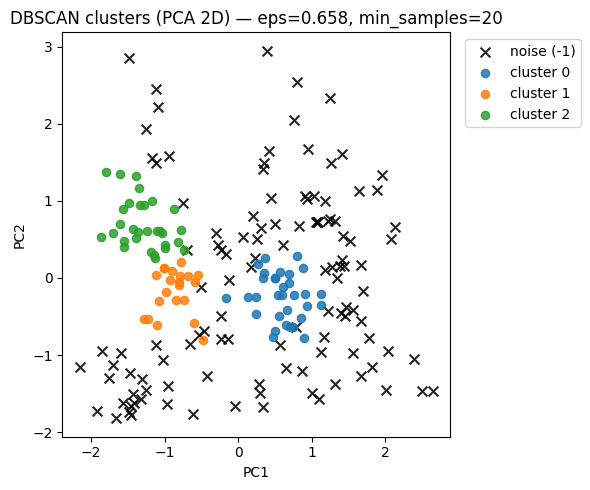

In [123]:
pca = PCA(n_components=2, random_state=42)
X2 = pca.fit_transform(Xz)

plt.figure(figsize=(6,5))
for lab in sorted(set(labels_db)):
    sel = labels_db == lab
    if lab == -1:
        plt.scatter(X2[sel,0], X2[sel,1], c="k", marker="x", s=50, alpha=0.85, label="noise (-1)")
    else:
        plt.scatter(X2[sel,0], X2[sel,1], s=35, alpha=0.85, label=f"cluster {lab}")
plt.title(f"DBSCAN clusters (PCA 2D) — eps={eps_best:.3f}, min_samples={ms_best}")
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.legend(bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout(); plt.show()

Interestingly, the PCA graph is showing a significant portion of the data as noise, with a distilled group of three clusters. This is a perk of DBSCAN - it does not assume anything about the cluster shapes. 

In [125]:
# Attach labels, show sizes
df_db = df_cust.copy()
df_db["dbscan_label"] = labels_db
sizes = df_db["dbscan_label"].value_counts().sort_index().rename("n")
display(sizes.to_frame())

# Profile non-noise clusters
def _gender_mix(s):
    d = s.value_counts(normalize=True)
    return {"pct_Female": 100*d.get("Female", d.get("F", 0.0)),
            "pct_Male":   100*d.get("Male",   d.get("M", 0.0))}
prof = (df_db[df_db["dbscan_label"] != -1]
        .groupby("dbscan_label", as_index=False)
        .agg({"Gender": _gender_mix,
              "Age":"mean",
              "Annual Income (k$)":"mean",
              "Spending Score (1-100)":"mean"}))
prof = pd.concat([prof.drop(columns=["Gender"]), prof["Gender"].apply(pd.Series)], axis=1)
prof = prof.rename(columns={"Age":"mean_age",
                            "Annual Income (k$)":"mean_income_k$",
                            "Spending Score (1-100)":"mean_spend_score"})
display(prof.sort_values("dbscan_label"))

,n
dbscan_label,
-1,117
0,32
1,21
2,30


,dbscan_label,mean_age,mean_income_k$,mean_spend_score,pct_Female,pct_Male
0,0,49.500000,53.593750,48.687500,62.500000,37.500000
1,1,22.047619,57.000000,51.095238,52.380952,47.619048
2,2,32.433333,80.466667,83.866667,56.666667,43.333333


The summary shows the number of clusters and a noise set labeled -1. 
• Cluster 0: mid-age, high income + middle spending (typical, responsible customers).
• Cluster 1: high income + low age (high spending young-adults).
• Cluster 2: High income + high spending (affluent, high engagement).

DBSCAN doesn’t force every point into a cluster. Low-density points are labeled noise (-1) and shown as black “x” markers in the PCA plot. K-Means and Ward assign every point to the nearest cluster, which can hide edge cases or create spurious tiny clusters. DBSCAN is therefore better at flagging unusual customers (e.g., very high income with very low spending, or rare combinations) and is robust to non-spherical shapes, so clusters can be elongated or curved.

From a tuning perspective, min_samples controls how strict “core points” must be; with higher values yield fewer clusters and more noise. eps controls neighborhood radius; increasing it merges clusters and reduces noise, while decreasing it splits clusters and increases noise. The k-distance plot can be used to pick a reasonable eps (look for the elbow), then sweep a small grid as above to find the optimal setting.

The PCA scatter shows DBSCAN clusters that do not align with K-Means/Ward core groups plus a noise set, primarily because such a large fraction of points were listed as noise. It's not inherently incorrect, because looking at our three clusters, we definitely see distinct groups. The data likely form three dominant segments with scattered edge cases, so DBSCAN is retaining the three clusters it found with the strongest signal. 

# (h) Model Evaluation & Analysis:

We begin by building a summary table, highlighting the silhoutte score and cluster number from each approach.

In [129]:
# Choose the SAME matrix you'll use for metrics (here: standardized numeric-only)
X_base = Xz   # or X_cust, but keep it consistent with X_for_metrics below

# pick best config from your sweep (g1 must exist)
best = g1.sort_values("silhouette", ascending=False).iloc[0]
k_sel  = int(best["k"])
cov_sel = str(best["cov"])
reg_sel = float(best["reg"])

# Fit GMM on X_base (not X_num) and get labels
gmm_final = GaussianMixture(
    n_components=k_sel,
    covariance_type=cov_sel,
    reg_covar=reg_sel,
    n_init=20,
    init_params="kmeans",
    random_state=42
).fit(X_base)

labels_gmm = gmm_final.predict(X_base)   # <<< save with this name

# pick feature matrix for metric computation
if 'X_cust' in globals():
    X_for_metrics = np.asarray(X_cust)
elif 'Xz' in globals():  # e.g., standardized numeric-only
    X_for_metrics = np.asarray(Xz)
else:
    raise RuntimeError("Please provide X_cust or Xz as the feature matrix for metrics.")

# collect the label vectors that exist in your namespace
entries = []

# K-Means
if 'labels_km' in globals():
    entries.append(("KMeans", np.asarray(labels_km)))
elif 'labels_final' in globals():
    entries.append(("KMeans", np.asarray(labels_final)))

# Hierarchical
if 'labels_hier' in globals() and isinstance(labels_hier, dict):
    for m in ["ward","average","complete","single"]:
        if m in labels_hier:
            entries.append((f"Hier-{m}", np.asarray(labels_hier[m])))

# GMM
if 'labels_gmm' in globals():
    entries.append(("GMM", np.asarray(labels_gmm)))

# SOM
if 'labels_som' in globals():
    entries.append(("SOM", np.asarray(labels_som)))

# DBSCAN
if 'labels_db' in globals():
    entries.append(("DBSCAN", np.asarray(labels_db)))

if not entries:
    raise RuntimeError("No clustering label arrays found. Define at least one set of labels.")

# --- helpers ---
def _n_clusters(labels):
    labs = np.asarray(labels)
    if np.any(labs == -1):
        return len(np.unique(labs[labs != -1]))
    return len(np.unique(labs))

def _noise_frac(labels):
    labs = np.asarray(labels)
    return float(np.mean(labs == -1)) if np.any(labs == -1) else 0.0

def _silhouette_wo_noise(X, labels):
    labs = np.asarray(labels)
    mask = (labs != -1) if np.any(labs == -1) else np.ones(len(labs), dtype=bool)
    if mask.sum() == 0:
        return None
    uniq = np.unique(labs[mask])
    if uniq.size < 2:
        return None
    try:
        return float(silhouette_score(X[mask], labs[mask]))
    except Exception:
        return None

# baseline for ARI/NMI (K-Means) if present
km_labels = None
for name, lab in entries:
    if name == "KMeans":
        km_labels = lab
        break

# build the table 
rows = []
for name, lab in entries:
    row = {
        "method": name,
        "n_clusters": _n_clusters(lab),
        "noise_frac": _noise_frac(lab),
        "silhouette": _silhouette_wo_noise(X_for_metrics, lab),
    }
    if km_labels is not None and name != "KMeans":
        try:
            row["ARI_vs_KMeans"] = float(adjusted_rand_score(km_labels, lab))
            row["NMI_vs_KMeans"] = float(normalized_mutual_info_score(km_labels, lab))
        except Exception:
            row["ARI_vs_KMeans"] = None
            row["NMI_vs_KMeans"] = None
    rows.append(row)

summary = pd.DataFrame(rows)

# nice ordering
cols = ["method","n_clusters","noise_frac","silhouette","ARI_vs_KMeans","NMI_vs_KMeans"]
summary = summary[[c for c in cols if c in summary.columns]]\
           .sort_values(["silhouette","n_clusters"], ascending=[False, False])\
           .reset_index(drop=True)

print("Clustering summary:")
display(summary)

Clustering summary:


,method,n_clusters,noise_frac,silhouette,ARI_vs_KMeans,NMI_vs_KMeans
0,DBSCAN,3,0.585,0.512983,0.213673,0.466357
1,GMM,6,0.000,0.354579,0.663660,0.747590
2,KMeans,4,0.000,0.350270,NaN,NaN
3,SOM,4,0.000,0.344610,0.892715,0.880122
4,Hier-average,4,0.000,0.332672,0.785566,0.790025
5,Hier-ward,4,0.000,0.329905,0.780302,0.770399
6,Hier-complete,4,0.000,0.241642,0.593039,0.636242
7,Hier-single,4,0.000,0.037187,-0.007182,0.046519


DBSCAN found 3 clusters with the best silhouette (0.513) but flagged ~58.5% of points as noise. That means the data has a few dense cores and a large halo of low-density or borderline cases. This is the only method that doesn’t force membership; so it’s great for explicit outlier handling, but the current eps/min_samples are quite strict (hence the large noise set).

K-Means produced 4 balanced clusters with silhouette 0.350. It’s a simple baseline.

SOM also gave 4 clusters with silhouette 0.345 and very high agreement with K-Means (ARI≈0.893, NMI≈0.880), confirming that the same macro-segments exist with the added benefit of the SOM map for topology.

Hierarchical (average/ward) matched K-Means closely (silhouettes 0.333/0.330, ARI≈0.786/0.780 vs K-Means). Complete over-splits edges (sil 0.242) and Single performs badly badly (sil 0.038) consistent with expectations.

GMM in this particular run shows 6 clusters, and ~0.35 silhoutte after restricting to numeric/PCA with tied/full covariance.

K-Means/SOM/Hier-(average/ward) showed 4 core segments that are highly consistent with one another (high ARI/NMI). Likely indicative of high-spend, low age, high spend middle age, low spend old age, and middle age low spend groupings.
GMM provided 6 elliptical segments with soft memberships that were not easily definable.

DBSCAN provided 3 clusters with a large noise signal.
DBSCAN explicitly labels low-density points as noise (-1) and does not always assign every point, so outliers get pulled into the nearest cluster and can blur boundaries.

K-Means / Ward / Average hierarachical clustering were all stable, fast, and easy to explain; and best when clusters are roughly globular and you want clean, balanced segments.

GMM should be chosen when clusters are elliptical/overlapping and you want soft membership probabilities; but stick to numeric/PCA features with tied/full covariance and BIC selection or you will get poor results.

Pick DBSCAN when you expect uneven density or weird shapes and need an explicit outlier/noise set; but you must tune eps/min_samples to control strictness.

Recommendation for this dataset:
I recommend using K-Means or Ward as the baseline for 4 explainable segments. Add GMM (numeric/PCA) if you need probabilistic memberships; and keep DBSCAN as the outlier lens or if you want more refined clusters, adjusting eps/min_samples if you want fewer/noise points.

# References
[1] Christopher M. Bishop. Neural Networks for Pattern Recognition. Oxford University Press, 1995.<br><br>
[2] Christopher Bishop. Pattern Recognition and Machine Learning. Springer, 2006. isbn: 0387310738.<br><br>
[3] Barry J. Shepherd C. Wayne Brown. Graphics File Formats: Reference and Guide. Manning
Publications, 1995. isbn: 1884777007.<br><br>
[4] Thomas H. Cormen et al. Introduction to Algorithms. 3rd. MIT Press, 2009. isbn: 780262033848.<br><br>
[5] W. R. Dillon and M. Goldstein. Multivariate Analysis Method and Applications. New York, NY:
John Wiley Sons, Inc, 1984.<br><br>
[6] Richard O. Duda, Peter E. Hart, and David G. Stork. Pattern Classification. 2nd. Wiley-
Interscience, 2000.<br><br>
[7] Duin et al. PRTools. https://cmp.felk.cvut.cz/cmp/software/stprtool/index.html.<br><br>
[8] L. Euler. “Nova Acta Acad. Sci. Petrop”. In: (1960).<br><br>
[9] R.A. Fisher. “The use of Multiple Measurements in Taxonomic Problems”. In: Proceedings of
Annals of Eugenics 7 (1936), pp. 179–188.<br><br>
[10] Vojtech Franc and Vaclav Hlavac. Statistical Pattern Recognition Toolbox. https://cmp.felk.
cvut.cz/cmp/software/stprtool/index.html.<br><br>
[11] Keinosuke Fukunaga. Introduction to Statistical Pattern Recognition. 1st. Academic Press, 1972.
isbn: 0122698509.<br><br>
[12] Keinosuke Fukunaga. Introduction to Statistical Pattern Recognition. 2nd. Academic Press, 1990.
isbn: 0122698517.<br><br>
[13] Herman H. Goldstine. A History of Numerical Analysis from the 16th through the 19th Century.
Springer New York, 1977. isbn: 978-0-387-90277-7.<br><br>
[14] H. Hotelling. “Analysis of a complex of statistical variables into principal components”. In: Jour-
nal of Educational Psychology 24 (1933), pp. 417–441.<br><br>
[15] Averill Law. Simulation Modeling and Analysis. 5th. Mcgraw-hill Series in Industrial Engineering
and Management, 2014.<br><br>
[16] Machine Learning at Waikato University. https://www.cs.waikato.ac.nz/~ml/index.html.<br><br>
[17] F. Pedregosa et al. “Scikit-learn: Machine Learning in Python”. In: Journal of Machine Learning
Research 12 (2011), pp. 2825–2830.<br><br>
[18] Casey J. Richards et al. “Multimodal data fusion using signal/image processing methods for
multi-class machine learning”. In: Signal Processing, Sensor/Information Fusion, and Target
Recognition XXXII. Ed. by Ivan Kadar, Erik P. Blasch, and Lynne L. Grewe. Vol. 12547. Inter-
national Society for Optics and Photonics. SPIE, 2023, 125470N. doi: 10.1117/12.2664987.
url: https://doi.org/10.1117/12.2664987.<br><br>
[19] Benjamin M. Rodriguez. “Multi-Class Classification for Identifying JPEG Steganography Em-
bedding Methods”. PhD thesis. Air Force Institute of Technology, 2008. url: https://scholar.
afit.edu/cgi/viewcontent.cgi?article=3642&context=etd.<br><br>
[20] Sergios Theodoridis and Konstantinos Koutroumbas. Pattern Recognition. 3rd. Academic Press,
2006. isbn: 0123695317.<br><br>